In [ ]:
pip install yfinance pandas numpy scikit-learn hmmlearn matplotlib seaborn networkx

In [ ]:
from hmmlearn.hmm import GaussianHMM
from google.colab import drive
import math
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import seaborn as sns
import random
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.stattools import adfuller
import time
import warnings
import yfinance as yf

In [ ]:
# Ruta en TU Drive (para cuando tú lo uses)
ruta_local = "/content/drive/MyDrive/datos_SPY_congelados.csv"

# Ruta pública en GitHub (para cuando lo use tu profesor)
url_publica = "https://raw.githubusercontent.com/Leo191219/Trabajo-de-Examen-Profesional-Leonardo-Marquez-Juarez/refs/heads/main/Datos%20Congelados"

if os.path.exists(ruta_local):
    print("🏠 Usando datos locales desde tu Google Drive...")
    data = pd.read_csv(ruta_local, index_col=0, parse_dates=True)
else:
    print("🌐 Drive no detectado (entorno externo). Cargando datos desde GitHub...")
    data = pd.read_csv(url_publica, index_col=0, parse_dates=True)

# CANDADO DE FECHA (Fundamental para el determinismo)
data = data.loc[:"2025-12-31"].copy()

🏠 Usando datos locales desde tu Google Drive...


#1.1. Objetivo: Extraer se˜nales a partir del ruido financiero

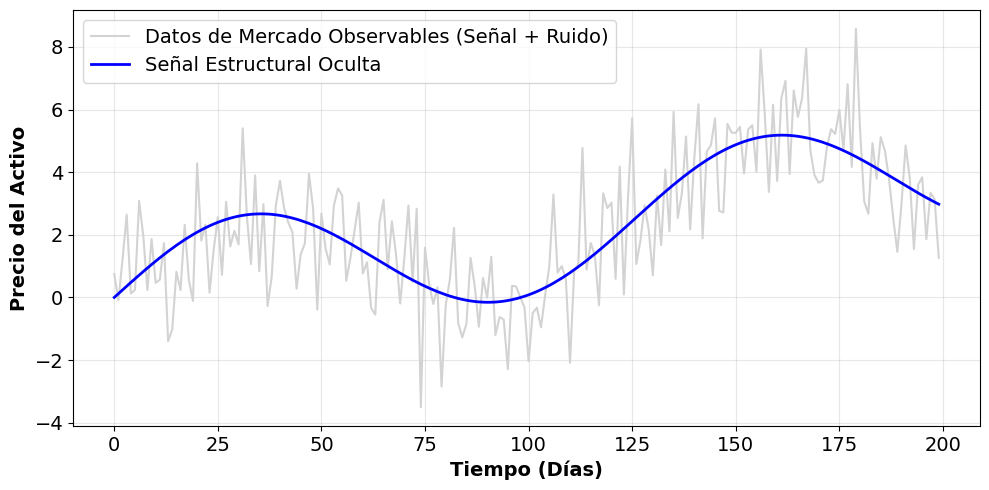

In [ ]:
# Establecer semilla para reproducibilidad
np.random.seed(42)

# 1. Generar la 'Señal Verdadera' (ej. una tendencia de mercado lenta y estructural)
dias = np.arange(200)
senal_verdadera = np.sin(dias / 20) * 2 + (dias / 50)

# 2. Generar el 'Ruido de Mercado' (estocasticidad de alta varianza)
ruido_mercado = np.random.normal(loc=0, scale=1.5, size=200)

# 3. Combinar para crear el 'Precio de Mercado Observable'
precio_observable = senal_verdadera + ruido_mercado

# Graficando el desafío descrito en la Sección 1.1
plt.figure(figsize=(10, 5))
plt.plot(dias, precio_observable, label='Datos de Mercado Observables (Señal + Ruido)', color='lightgray')
plt.plot(dias, senal_verdadera, label='Señal Estructural Oculta', color='blue', linewidth=2)
plt.xlabel('Tiempo (Días)', fontsize=14, fontweight='bold')
plt.ylabel('Precio del Activo', fontsize=14, fontweight='bold')
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#1.2. El Efecto "Promediado"

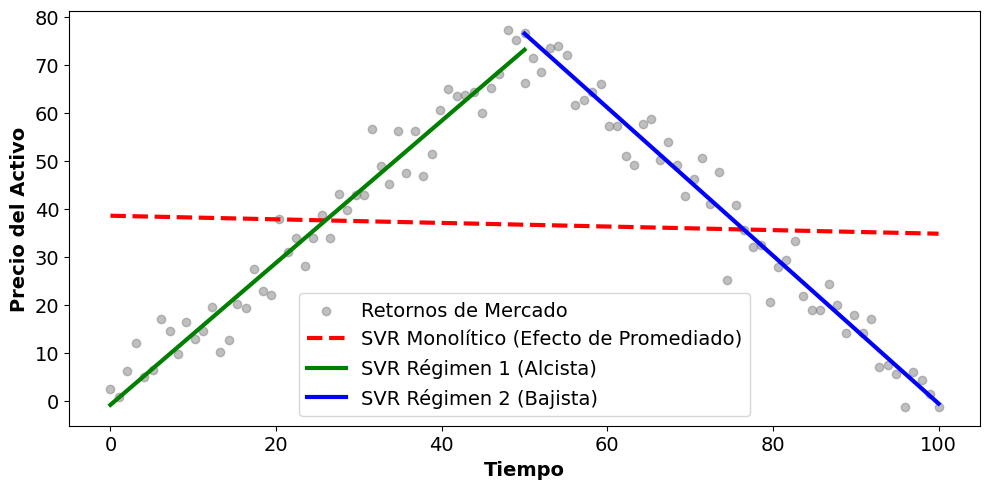

In [ ]:
# 1. Simular un Mercado No Estacionario (Dos Regímenes)
np.random.seed(42)

# Mercado Alcista Fuerte (Regímen 1)
X_alcista = np.linspace(0, 50, 50).reshape(-1, 1)
y_alcista = X_alcista.ravel() * 1.5 + np.random.normal(0, 5, 50)

# Mercado Bajista Fuerte (Régimen 2)
X_bajista = np.linspace(50, 100, 50).reshape(-1, 1)
y_bajista = - (X_bajista.ravel() - 50) * 1.5 + 75 + np.random.normal(0, 5, 50)

X_total = np.vstack((X_alcista, X_bajista))
y_total = np.concatenate((y_alcista, y_bajista))

# 2. Entrenar un SVR Monolítico (Forzándolo a encontrar un óptimo global)
svr_monolitico = SVR(kernel='linear', C=1.0)
svr_monolitico.fit(X_total, y_total)
y_pred_monolitico = svr_monolitico.predict(X_total)

# 3. Entrenar SVRs Específicos por Régimen (Tu Lógica Jerárquica)
svr_experto_alcista = SVR(kernel='linear', C=1.0).fit(X_alcista, y_alcista)
svr_experto_bajista = SVR(kernel='linear', C=1.0).fit(X_bajista, y_bajista)

# Graficando el VERDADERO Efecto de Promediado
plt.figure(figsize=(10, 5))
plt.scatter(X_total, y_total, color='gray', label='Retornos de Mercado', alpha=0.5)

# El fracaso Monolítico: ¡Dibuja una línea plana!
plt.plot(X_total, y_pred_monolitico, color='red', linewidth=3, linestyle='--',
          label='SVR Monolítico (Efecto de Promediado)')

# El éxito Jerárquico: Adaptándose a regímenes locales
plt.plot(X_alcista, svr_experto_alcista.predict(X_alcista), color='green',
         linewidth=3, label='SVR Régimen 1 (Alcista)')
plt.plot(X_bajista, svr_experto_bajista.predict(X_bajista), color='blue',
         linewidth=3, label='SVR Régimen 2 (Bajista)')

plt.xlabel('Tiempo', fontsize=14, fontweight='bold')
plt.ylabel('Precio del Activo', fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()


#1.3. No Estacionariedad

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_53345/2011946507.py:21: SyntaxWarning: invalid escape sequence '\e'
  label='+ Tubo $\epsilon$ Estático')
/tmp/ipykernel_53345/2011946507.py:23: SyntaxWarning: invalid escape sequence '\e'
  label='- Tubo $\epsilon$ Estático')


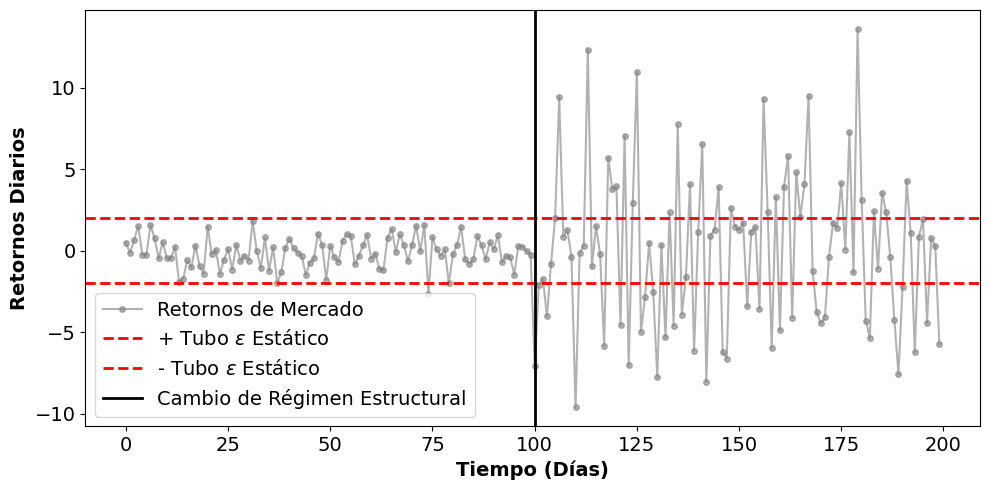

In [ ]:
# 1. Simular Varianza No Estacionaria (Cambio de Régimen de Volatilidad)
np.random.seed(42)
tiempo = np.arange(200)

# Régimen 0: Baja Volatilidad (Mercado Calmo)
mercado_calmo = np.random.normal(0, 1, 100)
# Régimen 1: Alta Volatilidad (Colapso de Mercado / Crisis)
mercado_volatil = np.random.normal(0, 5, 100)

retornos_no_estacionarios = np.concatenate((mercado_calmo, mercado_volatil))

# Tubo épsilon del SVR Monolítico (Tolerancia estática al ruido)
epsilon_estatico = 2.0

plt.figure(figsize=(10, 5))
plt.plot(tiempo, retornos_no_estacionarios, color='gray', label='Retornos de Mercado',
         marker='o', markersize=4, alpha=0.6)

# Graficando el umbral estático del SVR
plt.axhline(y=epsilon_estatico, color='red', linestyle='--', linewidth=2,
            label='+ Tubo $\epsilon$ Estático')
plt.axhline(y=-epsilon_estatico, color='red', linestyle='--', linewidth=2,
            label='- Tubo $\epsilon$ Estático')

# Marcando el cambio estructural
plt.axvline(x=100, color='black', linestyle='-', linewidth=2,
            label='Cambio de Régimen Estructural')

plt.xlabel('Tiempo (Días)', fontsize=14, fontweight='bold')
plt.ylabel('Retornos Diarios', fontsize=14, fontweight='bold')
plt.legend(fontsize=14, loc='lower left')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#1.4. La Maldición de la Dimensionalidad

Precisión solo con la señal: 0.99
Precisión tras agregar ruido: 0.85


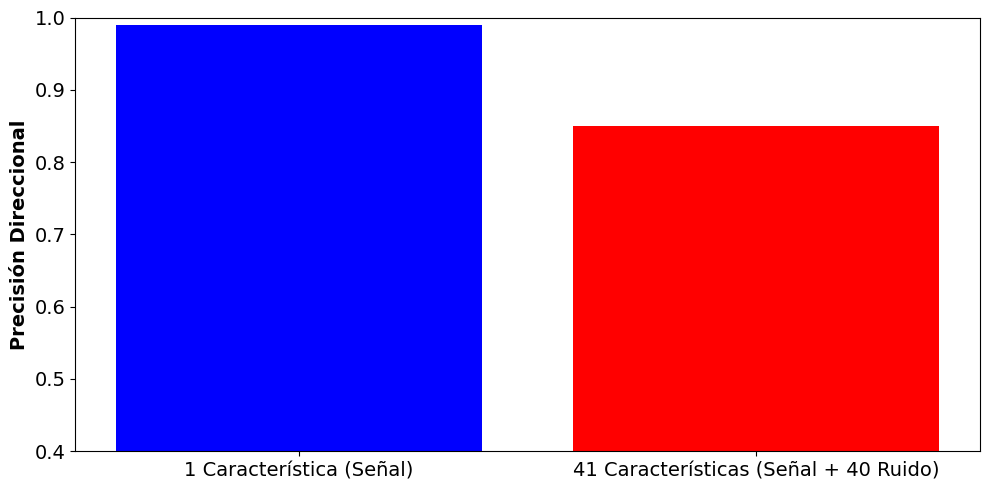

In [ ]:
# 1. Generar una "Señal Clara" (ej. si Momentum > 0, el precio sube)
np.random.seed(42)
n_muestras = 500
momentum = np.random.normal(0, 1, n_muestras)
target = (momentum > 0).astype(int) # 1 si sube, 0 si baja

# 2. Caso A: Baja Dimensionalidad (Solo la señal)
X_limpia = momentum.reshape(-1, 1)

# 3. Caso B: Alta Dimensionalidad (La "Maldición")
# Agregando 40 columnas de ruido aleatorio (ej. "Precipitación Diaria" o números al azar)
caracteristicas_ruido = np.random.normal(0, 1, (n_muestras, 40))
X_ruidosa = np.hstack([X_limpia, caracteristicas_ruido])

# 4. Función de Evaluación
def evaluar_modelo(X, y):
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

    # Escalar datos (¡SVR/SVC es sensible a la escala!)
    escalador = StandardScaler()
    X_entrenamiento = escalador.fit_transform(X_entrenamiento)
    X_prueba = escalador.transform(X_prueba)

    modelo = SVC(kernel='rbf')
    modelo.fit(X_entrenamiento, y_entrenamiento)
    predicciones = modelo.predict(X_prueba)

    return accuracy_score(y_prueba, predicciones)

precis_baja = evaluar_modelo(X_limpia, target)
precis_alta = evaluar_modelo(X_ruidosa, target)

# 5. Visualizar la "Dilución" de la señal
plt.figure(figsize=(10, 5))
plt.bar(['1 Característica (Señal)', '41 Características (Señal + 40 Ruido)'],
        [precis_baja, precis_alta], color=['blue', 'red'])
plt.ylabel('Precisión Direccional', fontsize=14,fontweight='bold')
plt.ylim(0.4, 1.0)

print(f"Precisión solo con la señal: {precis_baja:.2f}")
print(f"Precisión tras agregar ruido: {precis_alta:.2f}")

plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()



#2.1. Microestructura (LOB) Agregando Datos Diarios y Ingeniería de Características que Alimentan a los modelos.


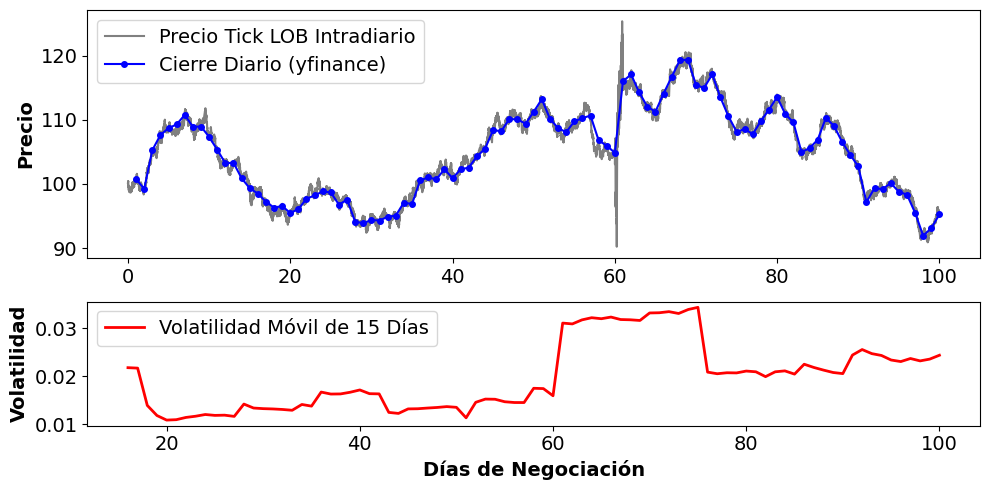

In [ ]:
# 1. Simular Datos de Alta Frecuencia del LOB (Limit Order Book)
np.random.seed(42)
dias = 100 # Incrementado a 100 días para asegurar datos suficientes para la ventana de 15 días
ticks_intradiarios = 390 # Minutos en un día de negociación estándar
total_ticks = dias * ticks_intradiarios

# Simular el rebote bid-ask del LOB y el ruido
retornos_lob = np.random.normal(0, 0.001, total_ticks)
# Inyectar un choque de liquidez severo alrededor del día 60
retornos_lob[60*ticks_intradiarios : 61*ticks_intradiarios] = np.random.normal(0, 0.01, ticks_intradiarios)

precios_tick = 100 * np.exp(np.cumsum(retornos_lob))

# 2. Agregar a Datos Diarios (Simulando yfinance)
# Extraer solo el último tick de cada bloque de 390 minutos para el "Cierre Diario"
cierres_diarios = precios_tick[ticks_intradiarios-1::ticks_intradiarios]
df_diario = pd.DataFrame({'Precio': cierres_diarios})

# Calcular las características de ingeniería (feature engineering)
df_diario['Retorno_Log'] = np.log(df_diario['Precio'] / df_diario['Precio'].shift(1))
df_diario['Vol_Movil_15'] = df_diario['Retorno_Log'].rolling(window=15).std()

# 3. Visualización
fig, axes = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})

# Gráfico 1: Intradiario vs. Diario
axes[0].plot(np.linspace(0, dias, total_ticks), precios_tick, color='gray', label='Precio Tick LOB Intradiario')
axes[0].plot(np.arange(1, dias+1), cierres_diarios, color='blue', marker='o', markersize=4, label='Cierre Diario (yfinance)')
axes[0].set_ylabel('Precio', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=14)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# Gráfico 2: La característica de volatilidad derivada
axes[1].plot(np.arange(1, dias+1), df_diario['Vol_Movil_15'], color='red', linewidth=2, label='Volatilidad Móvil de 15 Días')
axes[1].set_xlabel('Días de Negociación', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatilidad', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=14)

axes[1].tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#2.2. Regularización de Árboles de Decisiones: Restricciones Topologicas vs Sobreajuste


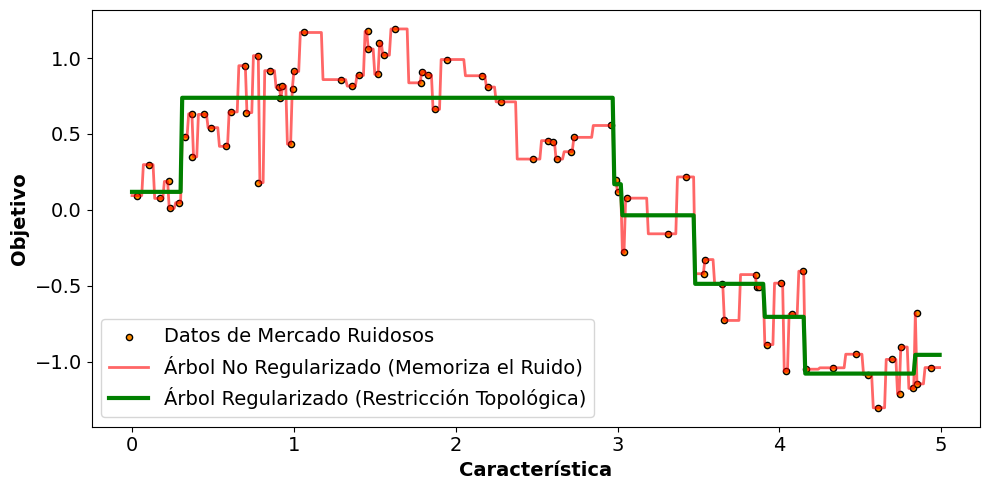

In [ ]:
# 1. Simular una tendencia de mercado ruidosa
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# 2. Entrenar un Árbol No Regularizado (Profundidad infinita = Sobreajuste)
tree_unregularized = DecisionTreeRegressor(max_depth=None)
tree_unregularized.fit(X, y)

# 3. Entrenar un Árbol Topológicamente Regularizado (max_depth=3)
tree_regularized = DecisionTreeRegressor(max_depth=3)
tree_regularized.fit(X, y)

# Predecir
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

# Visualizar
plt.figure(figsize=(10, 5))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos de Mercado Ruidosos")
plt.plot(X_test, tree_unregularized.predict(X_test), color="red", label="Árbol No Regularizado (Memoriza el Ruido)", linewidth=2, alpha=0.6)
plt.plot(X_test, tree_regularized.predict(X_test), color="green", label="Árbol Regularizado (Restricción Topológica)", linewidth=3)

plt.xlabel("Característica", fontsize=14, fontweight='bold')
plt.ylabel("Objetivo", fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#2.3. ¿Por qué el Ensamble Funciona? Varianza de un Árbol vs. Suavizamiento del Random Forest


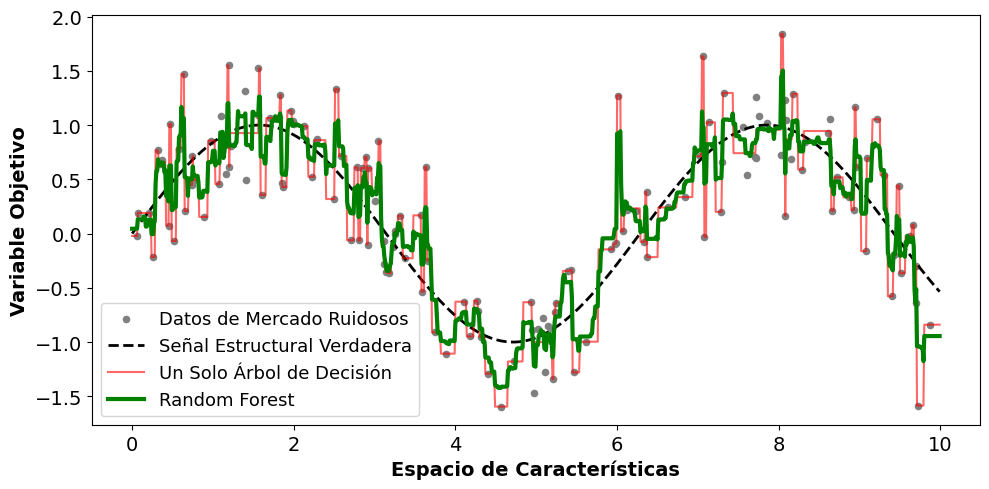

In [ ]:
# 1. Simular una tendencia estructural ruidosa
np.random.seed(42)
X = np.sort(10 * np.random.rand(150, 1), axis=0)
# Señal verdadera (onda senoidal) + Fuerte ruido de mercado
y = np.sin(X).ravel() + np.random.normal(0, 0.4, X.shape[0])

# 2. Entrenar un Solo Árbol de Decisión (Propenso a alta varianza/sobreajuste)
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X, y)

# 3. Entrenar un Random Forest (Ensamble de 100 árboles que reduce la varianza)
forest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
forest.fit(X, y)

# 4. Predecir
X_test = np.arange(0.0, 10.0, 0.01)[:, np.newaxis]
y_tree = tree.predict(X_test)
y_forest = forest.predict(X_test)

# 5. Visualización para tu Presentación de Defensa
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="gray", label="Datos de Mercado Ruidosos", s=20)
plt.plot(X_test, np.sin(X_test), color="black", label="Señal Estructural Verdadera", linewidth=2, linestyle="--")

# El fracaso de un solo árbol
plt.plot(X_test, y_tree, color="red", label="Un Solo Árbol de Decisión", linewidth=1.5, alpha=0.6)
# El éxito del ensamble
plt.plot(X_test, y_forest, color="green", label="Random Forest", linewidth=3)
plt.xlabel("Espacio de Características", fontsize=14, fontweight='bold')
plt.ylabel("Variable Objetivo", fontsize=14, fontweight='bold')
plt.legend(fontsize=13, loc='lower left')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#2.4 SVR: Ajustando Magnitudes Continuas (Izquierda) & SVC: Separando Clases Direccionales



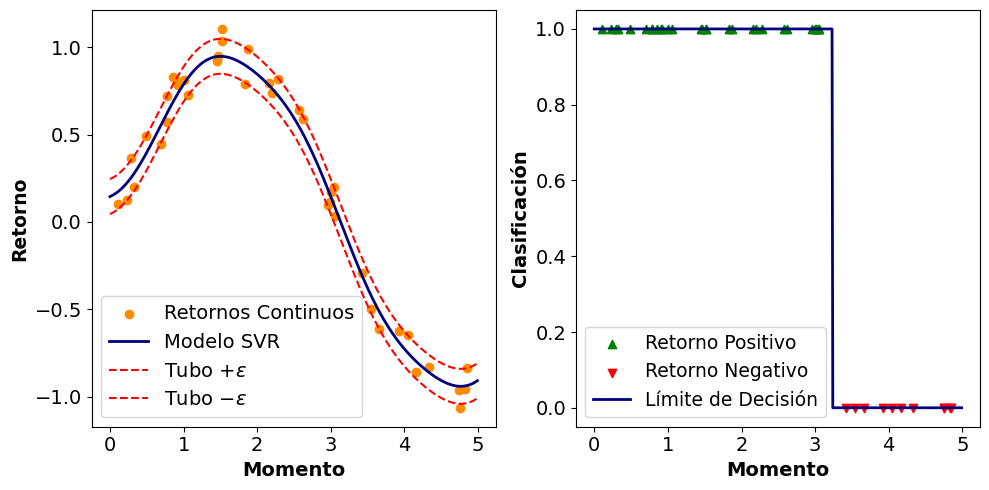

In [ ]:
# 1. Simular un espacio de características 2D simple (ej. Momento vs. Volatilidad)
np.random.seed(42)
X = np.sort(5 * np.random.rand(40, 1), axis=0)

# Objetivo Continuo (Para SVR)
y_continuous = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Objetivo Binario (Para SVC: ¿El retorno es positivo o negativo?)
y_binary = np.where(y_continuous > 0, 1, 0)

# 2. Entrenar Modelos
# SVR: Intenta ajustar los puntos DENTRO del tubo épsilon
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X, y_continuous)

# SVC: Intenta separar los puntos con un MARGEN
svc = SVC(kernel='rbf', C=100)
svc.fit(X, y_binary)

# 3. Visualización
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Graficar SVR
axes[0].scatter(X, y_continuous, color='darkorange', label='Retornos Continuos')
axes[0].plot(X_test, svr.predict(X_test), color='navy', lw=2, label='Modelo SVR')
# Nota: Usamos la 'r' antes del string para que Matplotlib interprete correctamente el símbolo de LaTeX
axes[0].plot(X_test, svr.predict(X_test) + svr.epsilon, color='red', linestyle='--', label=r'Tubo $+\epsilon$')
axes[0].plot(X_test, svr.predict(X_test) - svr.epsilon, color='red', linestyle='--', label=r'Tubo $-\epsilon$')
axes[0].legend(fontsize=14)
axes[0].set_ylabel('Retorno', fontsize=13.5, fontweight='bold')
axes[0].set_xlabel('Momento', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', which='major', labelsize=14)

# Graficar SVC
axes[1].scatter(X[y_binary == 1], np.ones(sum(y_binary == 1)), color='green', label='Retorno Positivo', marker='^')
axes[1].scatter(X[y_binary == 0], np.zeros(sum(y_binary == 0)), color='red', label='Retorno Negativo', marker='v')
axes[1].plot(X_test, svc.predict(X_test), color='navy', lw=2, label='Límite de Decisión')
axes[1].legend(fontsize=13.5, loc='lower left')
axes[1].set_ylabel('Clasificación', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Momento', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', which='major', labelsize=14)


plt.tight_layout()
plt.show()

#2.5. Eficiencia Computacional

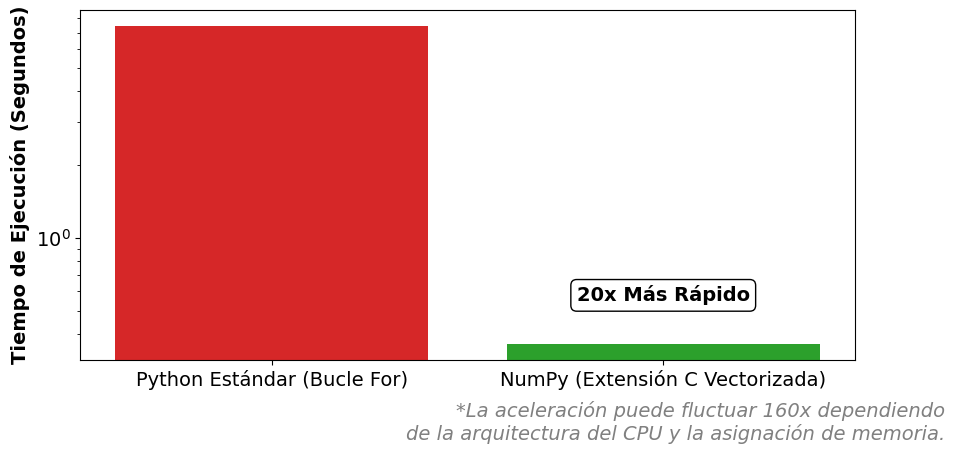

In [ ]:
# 1. Simular un conjunto de datos financieros a gran escala (10 millones de ticks)
np.random.seed(42)
financial_data = np.random.normal(0.0005, 0.01, 10_000_000)

# 2. Evaluación de rendimiento (Benchmark) con Bucle For ingenuo
start_time = time.time()
cumulative_returns_loop = []
current_sum = 0
for return_val in financial_data:
    current_sum += return_val
    cumulative_returns_loop.append(current_sum)
loop_time = time.time() - start_time

# 3. Evaluación de rendimiento con Vectorización de NumPy
start_time = time.time()
cumulative_returns_vectorized = np.cumsum(financial_data)
numpy_time = time.time() - start_time

speedup = loop_time / numpy_time

# 4. Generar el gráfico para la Tesis
methods = ['Python Estándar (Bucle For)', 'NumPy (Extensión C Vectorizada)']
times = [loop_time, numpy_time]

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, times, color=['#d62728', '#2ca02c'])

# Añadir etiquetas y formato
plt.ylabel('Tiempo de Ejecución (Segundos)', fontsize=14, fontweight='bold')
plt.yscale('log') # La escala logarítmica resalta la diferencia masiva

# Añadir el multiplicador de velocidad como texto
plt.text(1, numpy_time * 1.5, f'{speedup:.0f}x Más Rápido', ha='center',
         fontsize=14, fontweight='bold', color='black',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

plt.tick_params(axis='both', which='major', labelsize=14)

# Agregamos una nota elegante en la esquina inferior para explicar el asterisco
plt.figtext(0.99, 0.02, '*La aceleración puede fluctuar 160x dependiendo\nde la arquitectura del CPU y la asignación de memoria.',
            horizontalalignment='right', fontsize=14, style='italic', color='gray')

# Aumentamos un poco el margen inferior para que quepa la nota sin cortarse
plt.subplots_adjust(bottom=0.18)
plt.show()

#2.6, 2.7 & 2.8.

/tmp/ipykernel_53345/1277738722.py:32: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  plt.legend(*scatter.legend_elements(), labels=["Régimen 0", "Régimen 1"],fontsize=14)


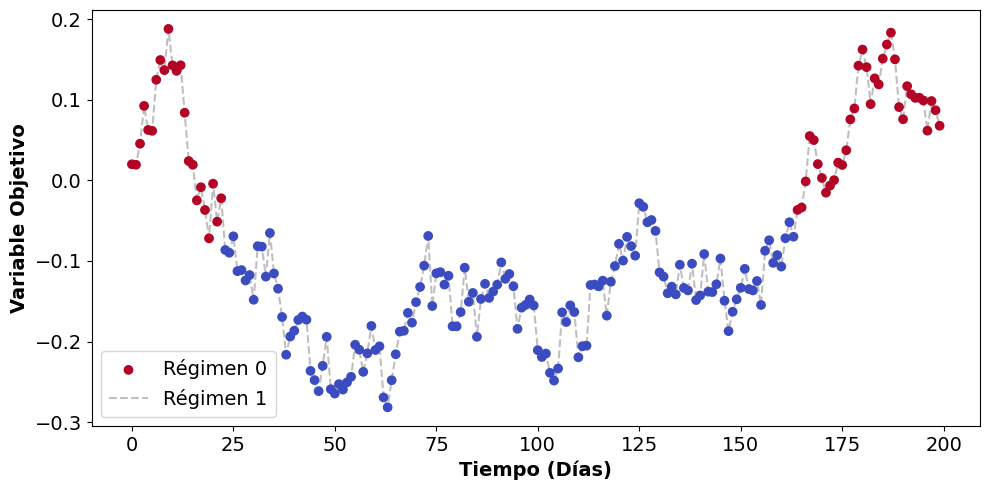

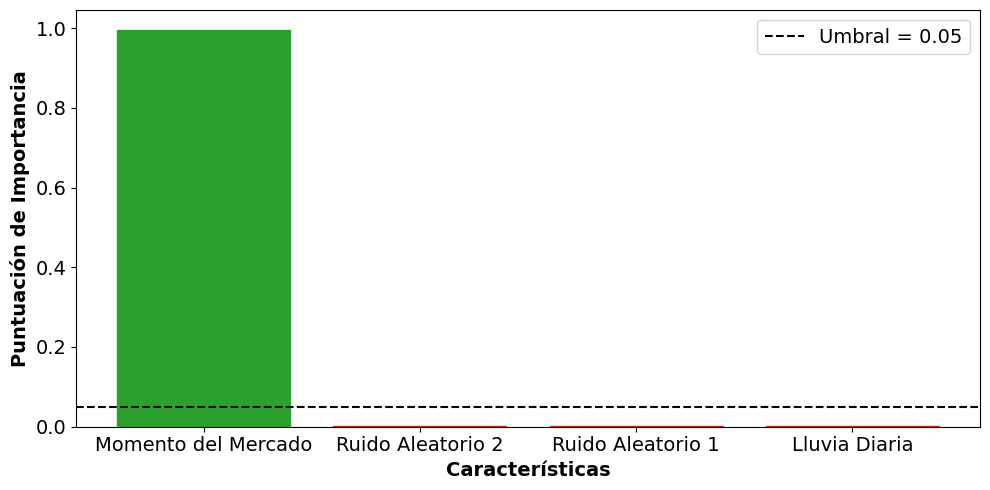

Características Importantes: ['Momento del Mercado']


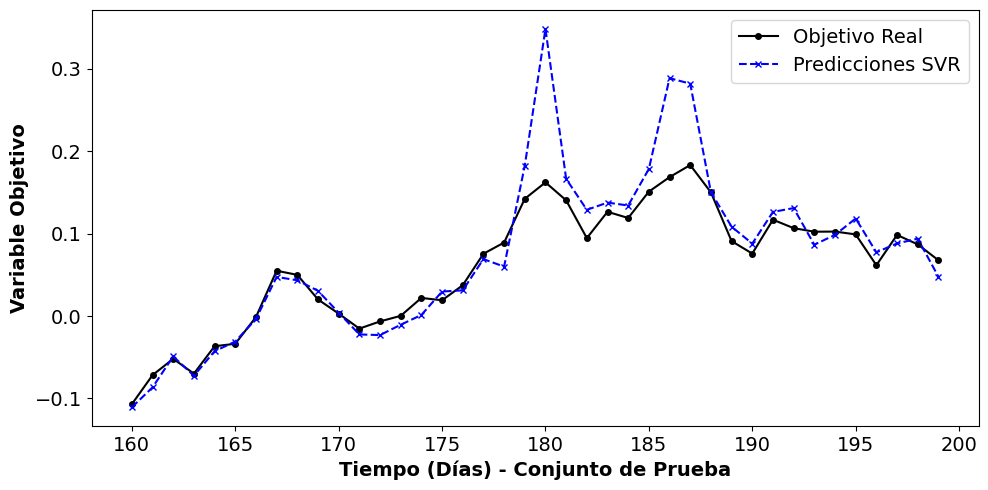

In [ ]:
# 0. Generación de conjunto de datos sintéticos (n=200)
np.random.seed(42)
n = 200

# Señal: Momento del Mercado
market_momentum = np.cumsum(np.random.normal(0.001, 0.02, n))
# Variable Objetivo (Retornos/Precio)
y = market_momentum * 1.5 + np.random.normal(0, 0.01, n)
y = pd.Series(y)

# Variables de Ruido
daily_rainfall = np.random.normal(5, 2, n)
noise_1 = np.random.normal(0, 1, n)
noise_2 = np.random.uniform(-1, 1, n)
X = pd.DataFrame({
    'Momento del Mercado': market_momentum,
    'Lluvia Diaria': daily_rainfall,
    'Ruido Aleatorio 1': noise_1,
    'Ruido Aleatorio 2': noise_2
})

# PASO 1. Identificación de regímenes (GHMM)
hmm_data = y.values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_data)
regimes_pred = model_hmm.predict(hmm_data)
plt.figure(figsize=(10, 5))
scatter = plt.scatter(range(n), y, c=regimes_pred, cmap='coolwarm', zorder=5)
plt.plot(y, color='gray', alpha=0.5, linestyle='--')
plt.xlabel('Tiempo (Días)', fontsize=14, fontweight='bold')
plt.ylabel('Variable Objetivo', fontsize=14, fontweight='bold')
plt.legend(*scatter.legend_elements(), labels=["Régimen 0", "Régimen 1"],fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# PASO 2. Eliminación de Ruido / IMPORTANCIA DE CARACTERÍSTICAS (RANDOM FOREST)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
bars = plt.bar(range(X.shape[1]), importances[indices], align="center")
# Colorear variables según el umbral de 0.05
for i, val in enumerate(importances[indices]):
    bars[i].set_color('#2ca02c' if val > 0.05 else '#d62728')
plt.xticks(range(X.shape[1]), features[indices], rotation=0)
plt.axhline(y=0.05, color='black', linestyle='--', label='Umbral = 0.05')
plt.ylabel('Puntuación de Importancia', fontsize=14, fontweight='bold')
plt.xlabel('Características', fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Descartar variables de ruido
important_features = features[importances > 0.05]
print("Características Importantes:", list(important_features))

# PASO 3. Pronóstico (REGRESIÓN DE VECTORES DE SOPORTE)
X_filtered = X[important_features]
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, shuffle=False)
svr = SVR(kernel='rbf', C=1e3, epsilon=0.01)
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test.values, label='Objetivo Real', color='black', marker='o', markersize=4)
plt.plot(y_test.index, y_pred, label='Predicciones SVR', color='blue', linestyle='--', marker='x', markersize=4)
plt.xlabel('Tiempo (Días) - Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.ylabel('Variable Objetivo', fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#3.0. Prueba ADF

In [ ]:
def probar_estacionariedad_en_universo():
    # El universo exacto de múltiples activos de la Tabla 3.9 de tu Tesis
    tickers = ["SPY", "QQQ", "IWM", "EEM", "GLD", "TLT", "XLE", "EWW", "VXX"]
    resultados = []

    print("Obteniendo datos y ejecutando pruebas de Dickey-Fuller Aumentada...\n")

    for ticker in tickers:
        try:
            # Descargar la misma línea de tiempo 2000-2025 utilizada en tu tesis
            datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)

            # Manejar columnas MultiIndex de yfinance si están presentes
            if isinstance(datos.columns, pd.MultiIndex):
                serie_precio = datos['Adj Close'].iloc[:, 0] if 'Adj Close' in datos.columns else datos['Close'].iloc[:, 0]
            else:
                serie_precio = datos['Adj Close'] if 'Adj Close' in datos.columns else datos['Close']

            # Paso 1: Calcular Retornos Logarítmicos continuamente compuestos
            retornos_log = np.log(serie_precio / serie_precio.shift(1)).dropna()

            # Paso 2: Realizar Prueba ADF
            resultado_adf = adfuller(retornos_log)
            valor_p = resultado_adf[1]
            estadistico_adf = resultado_adf[0]

            # Paso 3: Añadir resultados
            resultados.append({
                "Ticker": ticker,
                "Estadístico ADF": round(estadistico_adf, 4),
                "p-value": f"{valor_p:.4e}",
                "¿Es Estacionario (p < 0.05)?": "Sí" if valor_p < 0.05 else "No"
            })

        except Exception as e:
            resultados.append({
                "Ticker": ticker,
                "Estadístico ADF": "Error",
                "p-value": "Error",
                "¿Es Estacionario (p < 0.05)?": f"Falló: {str(e)}"
            })

    # Compilar en un DataFrame para fácil visualización
    df_resultados = pd.DataFrame(resultados)
    return df_resultados

# Ejecutar y mostrar la tabla resumen
tabla_resumen_adf = probar_estacionariedad_en_universo()
print(tabla_resumen_adf.to_string(index=False))

Obteniendo datos y ejecutando pruebas de Dickey-Fuller Aumentada...



/tmp/ipykernel_53345/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_53345/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_53345/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_53345/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_53345/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)


Ticker  Estadístico ADF    p-value ¿Es Estacionario (p < 0.05)?
   SPY         -20.2158 0.0000e+00                           Sí
   QQQ         -19.5029 0.0000e+00                           Sí
   IWM         -18.0328 2.6729e-30                           Sí
   EEM         -16.5919 1.7958e-29                           Sí
   GLD         -73.9038 0.0000e+00                           Sí
   TLT         -14.9519 1.2765e-27                           Sí
   XLE         -20.0580 0.0000e+00                           Sí
   EWW         -58.7042 0.0000e+00                           Sí
   VXX         -47.2422 0.0000e+00                           Sí


# Ultimate Baseline 1.0

1. Cargando datos...
-> Leyendo datos congelados desde tu Google Drive...
📊 Dataset listo. Tamaño total: 6538 filas.
Datos Listos. Conjunto de Entrenamiento: 5190 días. Conjunto de Prueba: 1298 días.

2. Entrenando GaussianHMM...
3. Ejecutando Filtro Random Forest...

 Importancia de Características 
SMA_15: 0.1018 -> CONSERVAR
SMA_50: 0.0875 -> CONSERVAR
Momentum_5D: 0.2241 -> CONSERVAR
Roll_Vol_15: 0.1697 -> CONSERVAR
Roll_Vol_30: 0.1396 -> CONSERVAR
Roll_Skew_30: 0.1403 -> CONSERVAR
Roll_Kurt_30: 0.1292 -> CONSERVAR
Regime: 0.0078 -> DESCARTAR

4. Entrenando SVR con características filtradas...

 Resultados del Pronóstico
RMSE (Raíz del Error Cuadrático Medio): 0.188265
Precisión Direccional (t+1): 47.69%

 RESULTADOS FINANCIEROS: ESTRATEGIA SVR
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 15.91% | Drawdown: -14.14% | Sharpe: 0.45



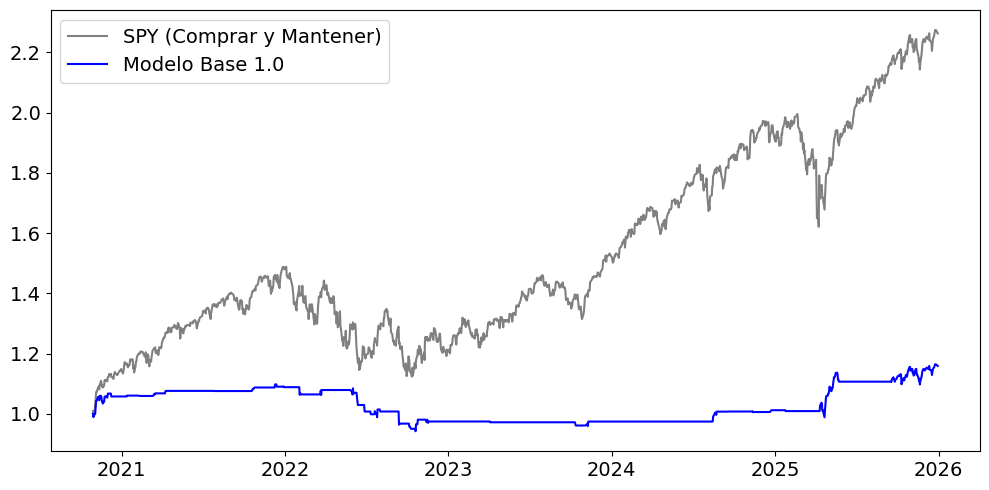


 6. Optimización: CLASIFICADOR DE VECTORES DE SOPORTE (SVC) Y BÚSQUEDA EN CUADRÍCULA
Iniciando Búsqueda en Cuadrícula (Grid Search)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 ¡Optimización Completada!
Mejores Parámetros Encontrados: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}

 Resultados del pronóstico optimizado (FUERA DE MUESTRA)
Precisión Direccional Optimizada (t+1): 54.78%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Baja (0)       0.00      0.00      0.00       587
    Alza (1)       0.55      1.00      0.71       711

    accuracy                           0.55      1298
   macro avg       0.27      0.50      0.35      1298
weighted avg       0.30      0.55      0.39      1298



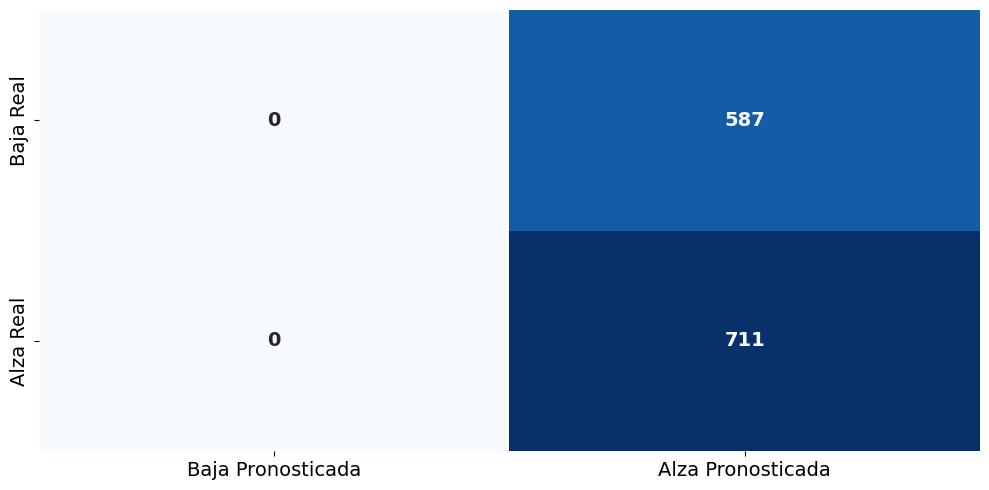

In [ ]:
# --- CANDADOS DE DETERMINISMO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
print("1. Cargando datos...")
ticker = "SPY"

# --- RUTAS HÍBRIDAS PARA COLAB ---
# 1. Tu Drive privado (asegúrate de correr drive.mount('/content/drive') en una celda arriba)
ruta_local = "/content/drive/MyDrive/datos_SPY_congelados.csv"
# 2. Tu repositorio de GitHub (cambia la URL por tu link RAW real)
url_publica = "https://raw.githubusercontent.com/Leo191219/Trabajo-de-Examen-Profesional-Leonardo-Marquez-Juarez/refs/heads/main/Datos%20Congelados"

# EL TRUCO MEJORADO: Busca en Drive, si no, busca en GitHub.
if os.path.exists(ruta_local):
    print("-> Leyendo datos congelados desde tu Google Drive...")
    data = pd.read_csv(ruta_local, index_col=0, parse_dates=True)
else:
    print("-> Drive no detectado (entorno de sinodal). Leyendo datos oficiales desde GitHub...")
    data = pd.read_csv(url_publica, index_col=0, parse_dates=True)

# --- CANDADO DE FECHA ESTRICTO ---
# Cortamos la serie exactamente para la evaluación de la tesis (2000-2025)
data = data.loc[:"2025-12-31"].copy()

print(f"📊 Dataset listo. Tamaño total: {len(data)} filas.")

# Identificar la columna de precio correcta
price_column = 'Adj Close'
if price_column not in data.columns:
    price_column = 'Close'

# Objetivo: Retornos Logarítmicos Diarios
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))

# Indicadores Técnicos (Momento y Tendencia)
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1

# Indicadores Estadísticos (Volatilidad y Riesgo)
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

# Definiendo variables independientes (X) y variable dependiente (y)
feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
X_raw = data[feature_cols]
y_raw = data['Log_Return']

# REZAGO: Previniendo el sesgo de anticipación (Alineando X en t-1 con y en t)
X_lagged = X_raw.shift(1)

# Fusionar y eliminar NaNs (Causados por las ventanas móviles y el rezago)
dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()
y = dataset['Log_Return']
X = dataset[feature_cols]

# DIVISIÓN CRONOLÓGICA (80% Entrenamiento, 20% Prueba)
split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Datos Listos. Conjunto de Entrenamiento: {len(X_train)} días. Conjunto de Prueba: {len(X_test)} días.")

# 2. PASO 1: IDENTIFICACIÓN DE REGÍMENES (GHMM)
print("\n2. Entrenando GaussianHMM...")
# Entrenando el HMM usando retornos del conjunto de entrenamiento
hmm_train_data = y_train.values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_train_data)

# Prediciendo regímenes
regimes_train = model_hmm.predict(hmm_train_data)
hmm_test_data = y_test.values.reshape(-1, 1)
regimes_test = model_hmm.predict(hmm_test_data)

# Añadir los regímenes como una nueva característica (señal estructural)
X_train['Regime'] = regimes_train
X_test['Regime'] = regimes_test
feature_cols.append('Regime') # Actualizar feature_cols para incluir 'Regime'

# 3. PASO 2: ELIMINACIÓN DE RUIDO Y SELECCIÓN DE CARACTERÍSTICAS (RANDOM FOREST)
print("3. Ejecutando Filtro Random Forest...")
# n_jobs=1 fuerza un solo hilo para garantizar determinismo estricto
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

# Extrayendo importancias de características y aplicando umbral
importances = rf.feature_importances_
threshold = 0.05
important_features = []

print("\n Importancia de Características ")
for feature, imp in zip(feature_cols, importances):
    status = "CONSERVAR" if imp > threshold else "DESCARTAR"
    if status == "CONSERVAR": important_features.append(feature)
    print(f"{feature}: {imp:.4f} -> {status}")

X_train_filtered = X_train[important_features]
X_test_filtered = X_test[important_features]

# 4. PASO 3: PRONÓSTICO (REGRESIÓN DE VECTORES DE SOPORTE)
print("\n4. Entrenando SVR con características filtradas...")
# Nota: SVR es sensible a la escala; estandarizando los datos filtrados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

svr = SVR(kernel='rbf', C=100, epsilon=0.001)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

# 5. MÉTRICAS Y EVALUACIÓN
print("\n Resultados del Pronóstico")

# 5.1. RMSE (Raíz del Error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.6f}")

# 5.2. Precisión Direccional (¿Fue correcta la predicción de si el precio subía o bajaba?)
y_test_dir = np.where(y_test > 0, 1, 0)
y_pred_dir = np.where(y_pred > 0, 1, 0)
dir_acc = accuracy_score(y_test_dir, y_pred_dir)
print(f"Precisión Direccional (t+1): {dir_acc * 100:.2f}%")

# 5.3. BACKTESTING FINANCIERO: ESTRATEGIA SVR VS COMPRAR Y MANTENER
backtest_df_svr = pd.DataFrame(index=y_test.index)
backtest_df_svr['Market_Returns'] = y_test
backtest_df_svr['Signal'] = y_pred_dir

# El retorno de la estrategia usa la predicción de AYER para el retorno del mercado de HOY
backtest_df_svr['Strategy_Returns'] = backtest_df_svr['Market_Returns'] * backtest_df_svr['Signal'].shift(1)
backtest_df_svr.fillna(0, inplace=True)

backtest_df_svr['Cum_Market'] = np.exp(backtest_df_svr['Market_Returns'].cumsum())
backtest_df_svr['Cum_Strategy'] = np.exp(backtest_df_svr['Strategy_Returns'].cumsum())

total_mkt_svr = (backtest_df_svr['Cum_Market'].iloc[-1] - 1) * 100
total_str_svr = (backtest_df_svr['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt_svr = ((backtest_df_svr['Cum_Market'] / backtest_df_svr['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str_svr = ((backtest_df_svr['Cum_Strategy'] / backtest_df_svr['Cum_Strategy'].cummax()) - 1).min() * 100

sharpe_mkt_svr = np.sqrt(252) * (backtest_df_svr['Market_Returns'].mean() / backtest_df_svr['Market_Returns'].std())
sharpe_str_svr = np.sqrt(252) * (backtest_df_svr['Strategy_Returns'].mean() / backtest_df_svr['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: ESTRATEGIA SVR")
print(f"Mercado    -> Retorno Total: {total_mkt_svr:.2f}% | Drawdown: {max_dd_mkt_svr:.2f}% | Sharpe: {sharpe_mkt_svr:.2f}")
print(f"Estrategia -> Retorno Total: {total_str_svr:.2f}% | Drawdown: {max_dd_str_svr:.2f}% | Sharpe: {sharpe_str_svr:.2f}\n")

plt.figure(figsize=(10, 5))
plt.plot(backtest_df_svr.index, backtest_df_svr['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray')
plt.plot(backtest_df_svr.index, backtest_df_svr['Cum_Strategy'], label='Modelo Base 1.0', color='blue')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

print("\n 6. Optimización: CLASIFICADOR DE VECTORES DE SOPORTE (SVC) Y BÚSQUEDA EN CUADRÍCULA")

# 6.1. Transformar la variable objetivo en una clase binaria (Direccionalidad).
# 1 = Retorno Positivo (Alza), 0 = Retorno Negativo (Baja)
y_train_class = np.where(y_train > 0, 1, 0)
y_test_class = np.where(y_test > 0, 1, 0)

# 6.2. Validación Cruzada de Series Temporales (Evitando Sesgo de Anticipación)
tscv = TimeSeriesSplit(n_splits=5)

# 6.3. Espacio de búsqueda de hiperparámetros
param_grid = {
    'C': [0.1, 1, 10, 100],           # Término de penalización de error
    'gamma': ['scale', 'auto', 0.01, 0.1, 1], # Coeficiente para el Kernel RBF
    'kernel': ['rbf']                 # RBF para no linealidad financiera
}

print("Iniciando Búsqueda en Cuadrícula (Grid Search)...")

# 6.4. Instanciando el modelo base y el optimizador (n_jobs=1 para determinismo)
svc_base = SVC(random_state=42)
grid_search = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy', # Optimizado para maximizar la Precisión Direccional
    n_jobs=1,
    verbose=1
)

# 6.5. Entrenar el optimizador
grid_search.fit(X_train_scaled, y_train_class)

# Extraer el mejor modelo
best_svc = grid_search.best_estimator_
print(f"\n ¡Optimización Completada!")
print(f"Mejores Parámetros Encontrados: {grid_search.best_params_}")

# 7. Evaluación del Modelo Optimizado (FUERA DE MUESTRA)
print("\n Resultados del pronóstico optimizado (FUERA DE MUESTRA)")

# Generar predicciones usando el modelo optimizado
y_pred_class = best_svc.predict(X_test_scaled)

# Calcular la nueva precisión direccional
opt_dir_acc = accuracy_score(y_test_class, y_pred_class)
print(f"Precisión Direccional Optimizada (t+1): {opt_dir_acc * 100:.2f}%\n")

# Reporte de clasificación detallado
print("Reporte de Clasificación:")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))

# El parámetro annot_kws ajusta el tamaño de los números DENTRO de la matriz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"}) # <--- Aquí controlas el texto interior

# plt.tick_params ajusta el tamaño de las etiquetas de los ejes (los nombres de las clases)
plt.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

# Ultimate Baseline 2.0

1. Cargando datos...
-> Leyendo datos congelados desde tu Google Drive...
📊 Dataset listo. Tamaño total: 6538 filas.
Datos Listos. Entrenamiento: 5190 días. Prueba: 1298 días.

2. Entrenando GaussianHMM...
3. Ejecutando Filtro Random Forest...

 Importancia de Características 
SMA_15: 0.1018 -> CONSERVAR
SMA_50: 0.0875 -> CONSERVAR
Momentum_5D: 0.2241 -> CONSERVAR
Roll_Vol_15: 0.1697 -> CONSERVAR
Roll_Vol_30: 0.1396 -> CONSERVAR
Roll_Skew_30: 0.1403 -> CONSERVAR
Roll_Kurt_30: 0.1292 -> CONSERVAR
Regime: 0.0078 -> DESCARTAR

4. Entrenando SVC Binario (Modelo 2.0)...

 Resultados del Pronóstico (Modelo Base 2.0)
Precisión Direccional (t+1): 55.62%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Baja (0)       0.65      0.04      0.08       587
    Alza (1)       0.55      0.98      0.71       711

    accuracy                           0.56      1298
   macro avg       0.60      0.51      0.39      1298
weighted avg       0.60      0.56      0.42    

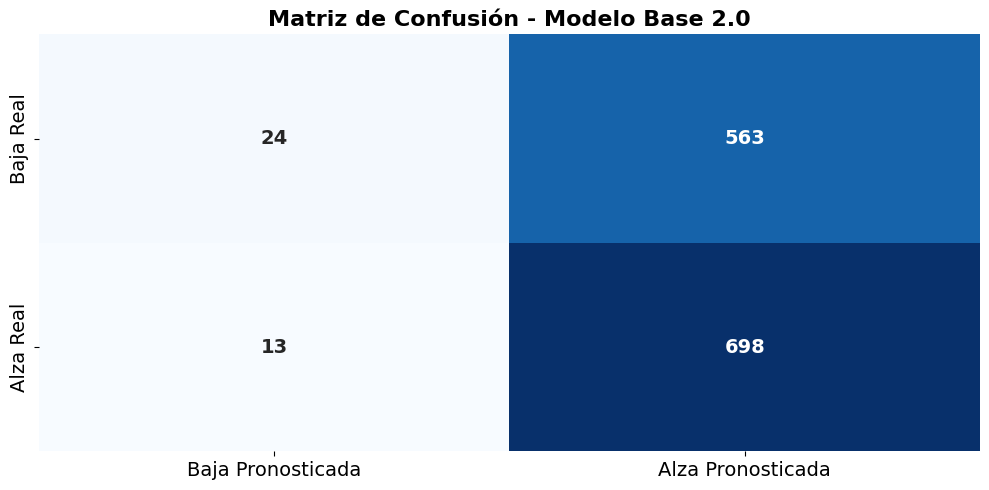


 RESULTADOS FINANCIEROS: MODELO BASE 2.0
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 159.10% | Drawdown: -18.76% | Sharpe: 1.11



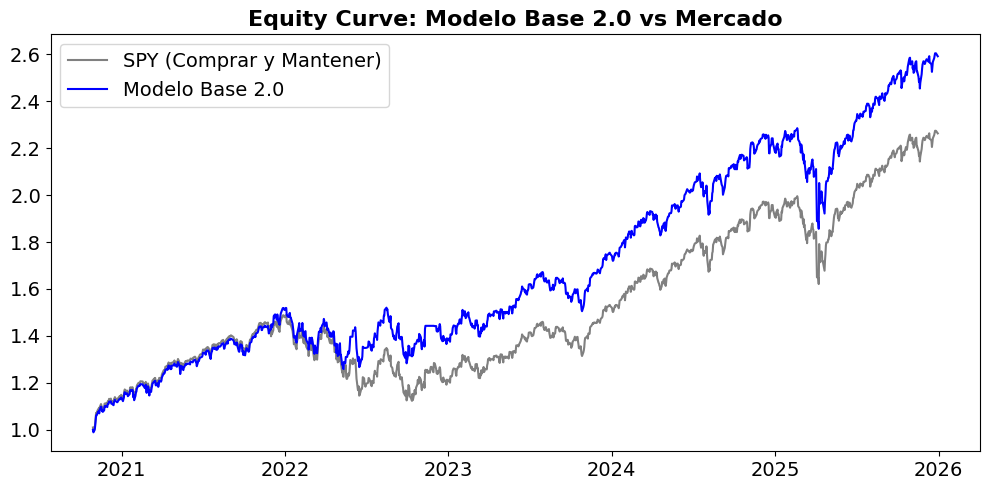

In [ ]:
# --- CANDADOS DE DETERMINISMO TOTAL ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================
print("1. Cargando datos...")
ticker = "SPY"

# --- RUTAS HÍBRIDAS PARA COLAB ---
ruta_local = "/content/drive/MyDrive/datos_SPY_congelados.csv"
url_publica = "https://raw.githubusercontent.com/LeonardoMarquezJuarez/TU_REPOSITORIO/main/datos_SPY_congelados.csv"

# EL TRUCO MEJORADO: Busca en Drive, si no, busca en GitHub.
if os.path.exists(ruta_local):
    print("-> Leyendo datos congelados desde tu Google Drive...")
    data = pd.read_csv(ruta_local, index_col=0, parse_dates=True)
else:
    print("-> Drive no detectado (entorno externo). Leyendo datos oficiales desde GitHub...")
    data = pd.read_csv(url_publica, index_col=0, parse_dates=True)

# --- CANDADO DE FECHA ESTRICTO ---
data = data.loc[:"2025-12-31"].copy()
print(f"📊 Dataset listo. Tamaño total: {len(data)} filas.")

# Identificar la columna de precio correcta
price_column = 'Adj Close' if 'Adj Close' in data.columns else 'Close'

# Objetivo: Retornos Logarítmicos Diarios
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))

# Indicadores Técnicos (Momento y Tendencia)
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1

# Indicadores Estadísticos (Volatilidad y Riesgo)
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

# Definiendo variables independientes (X) y variable dependiente (y)
feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
X_raw = data[feature_cols]
y_raw = data['Log_Return']

# REZAGO: Previniendo el sesgo de anticipación (X en t-1 predice y en t)
X_lagged = X_raw.shift(1)

# Fusionar y eliminar NaNs
dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()
y = dataset['Log_Return']
X = dataset[feature_cols]

# DIVISIÓN CRONOLÓGICA (80% Entrenamiento, 20% Prueba)
split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Datos Listos. Entrenamiento: {len(X_train)} días. Prueba: {len(X_test)} días.")

# ==============================================================================
# 2. PASO 1: IDENTIFICACIÓN DE REGÍMENES (GHMM) CON CANDADO ANTI-LABEL SWITCHING
# ==============================================================================
print("\n2. Entrenando GaussianHMM...")
hmm_train_data = y_train.values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_train_data)

# Predicción inicial
regimes_train_raw = model_hmm.predict(hmm_train_data)
regimes_test_raw = model_hmm.predict(y_test.values.reshape(-1, 1))

# --- CANDADO ANTI-LABEL SWITCHING ---
var_estado_0 = np.var(hmm_train_data[regimes_train_raw == 0])
var_estado_1 = np.var(hmm_train_data[regimes_train_raw == 1])

if var_estado_0 > var_estado_1:
    regimes_train = 1 - regimes_train_raw
    regimes_test = 1 - regimes_test_raw
else:
    regimes_train = regimes_train_raw
    regimes_test = regimes_test_raw

X_train['Regime'] = regimes_train
X_test['Regime'] = regimes_test
feature_cols.append('Regime')

# ==============================================================================
# 3. PASO 2: ELIMINACIÓN DE RUIDO (RANDOM FOREST)
# ==============================================================================
print("3. Ejecutando Filtro Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
threshold = 0.05
important_features = []

print("\n Importancia de Características ")
for feature, imp in zip(feature_cols, importances):
    status = "CONSERVAR" if imp > threshold else "DESCARTAR"
    if status == "CONSERVAR": important_features.append(feature)
    print(f"{feature}: {imp:.4f} -> {status}")

X_train_filtered = X_train[important_features]
X_test_filtered = X_test[important_features]

# ==============================================================================
# 4. PASO 3: PRONÓSTICO (MODELO 2.0: SVC BINARIO NO PENALIZADO)
# ==============================================================================
print("\n4. Entrenando SVC Binario (Modelo 2.0)...")

# TRANSFORMACIÓN CLAVE PARA MODELO 2.0: De retornos continuos a Clases Binarias
y_train_class = np.where(y_train > 0, 1, 0)
y_test_class = np.where(y_test > 0, 1, 0)

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

# SVC SIN EQUILIBRIO DE CLASES (Esto causa la hipersensibilidad al riesgo de la tesis)
svc_modelo_2 = SVC(kernel='rbf', random_state=42)
svc_modelo_2.fit(X_train_scaled, y_train_class)
y_pred_class = svc_modelo_2.predict(X_test_scaled)

# ==============================================================================
# 5. MÉTRICAS Y BACKTESTING FINANCIERO
# ==============================================================================
print("\n Resultados del Pronóstico (Modelo Base 2.0)")

dir_acc = accuracy_score(y_test_class, y_pred_class)
print(f"Precisión Direccional (t+1): {dir_acc * 100:.2f}%\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"})
plt.tick_params(axis='both', which='major', labelsize=14)
plt.title('Matriz de Confusión - Modelo Base 2.0', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Backtesting Financiero
backtest_df = pd.DataFrame(index=y_test.index)
backtest_df['Market_Returns'] = y_test
backtest_df['Signal'] = y_pred_class

# El retorno es el mercado de hoy si la señal de ayer fue 1 (Alza)
backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
backtest_df.fillna(0, inplace=True)

backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

total_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
total_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100

sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: MODELO BASE 2.0")
print(f"Mercado    -> Retorno Total: {total_mkt:.2f}% | Drawdown: {max_dd_mkt:.2f}% | Sharpe: {sharpe_mkt:.2f}")
print(f"Estrategia -> Retorno Total: {total_str:.2f}% | Drawdown: {max_dd_str:.2f}% | Sharpe: {sharpe_str:.2f}\n")

plt.figure(figsize=(10, 5))
plt.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray')
plt.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo Base 2.0', color='blue')
plt.title('Equity Curve: Modelo Base 2.0 vs Mercado', fontsize=16, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Ultimate Baseline 3.0

1. Cargando datos...
-> Leyendo datos congelados desde tu Google Drive...
📊 Dataset listo. Tamaño total: 6538 filas.
Datos Listos. Entrenamiento: 5190 días. Prueba: 1298 días.

2. Entrenando SVC Penalizado (Modelo Base 3.0)...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

¡Optimización Completada!
Mejores Parámetros Encontrados: {'C': 100, 'gamma': 'auto'}

 Resultados del Pronóstico (Dentro de Muestra vs Fuera de Muestra)
Precisión Direccional de Entrenamiento: 61.91%
RMSE de Entrenamiento: 0.617191
Precisión Direccional Fuera de Muestra: 47.30%
RMSE Fuera de Muestra: 0.725923

Reporte de Clasificación (Enfocado en Riesgo - Modelo 3.0):
              precision    recall  f1-score   support

    Baja (0)       0.45      0.83      0.59       587
    Alza (1)       0.56      0.18      0.27       711

    accuracy                           0.47      1298
   macro avg       0.51      0.50      0.43      1298
weighted avg       0.51      0.47      0.42      1298



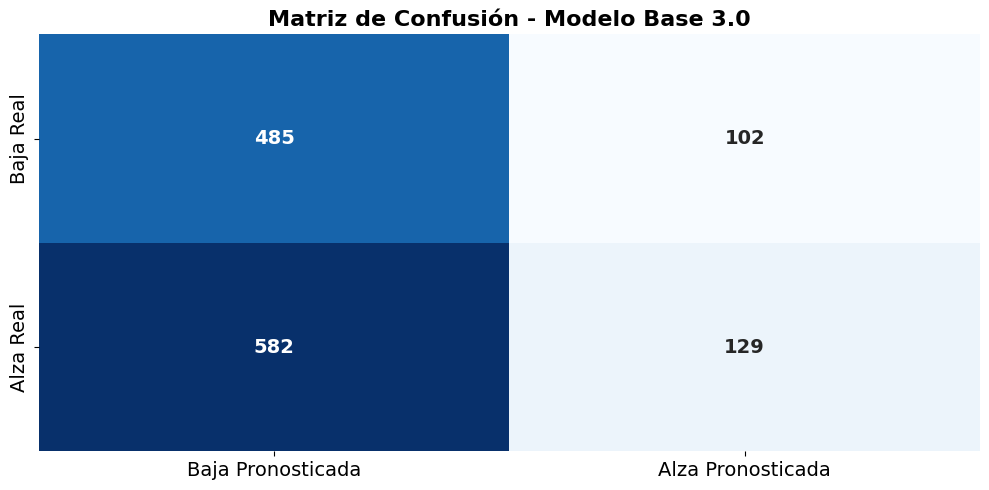


 3. BACKTESTING FINANCIERO: ESTRATEGIA SVC PENALIZADA

 RESULTADOS FINANCIEROS: MODELO BASE 3.0
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 21.57% | Drawdown: -12.24% | Sharpe: 0.51



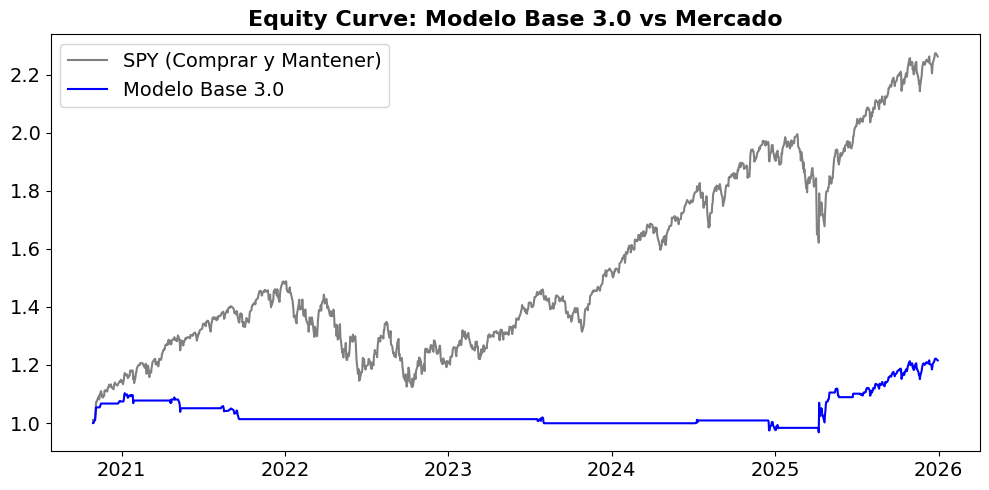

In [29]:
# --- CANDADOS DE DETERMINISMO TOTAL ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================
print("1. Cargando datos...")
ticker = "SPY"

# --- RUTAS HÍBRIDAS PARA COLAB ---
ruta_local = "/content/drive/MyDrive/datos_SPY_congelados.csv"
url_publica = "https://raw.githubusercontent.com/LeonardoMarquezJuarez/TU_REPOSITORIO/main/datos_SPY_congelados.csv"

# EL TRUCO MEJORADO: Busca en Drive, si no, busca en GitHub.
if os.path.exists(ruta_local):
    print("-> Leyendo datos congelados desde tu Google Drive...")
    data = pd.read_csv(ruta_local, index_col=0, parse_dates=True)
else:
    print("-> Drive no detectado (entorno externo). Leyendo datos oficiales desde GitHub...")
    data = pd.read_csv(url_publica, index_col=0, parse_dates=True)

# --- CANDADO DE FECHA ESTRICTO ---
data = data.loc[:"2025-12-31"].copy()
print(f"📊 Dataset listo. Tamaño total: {len(data)} filas.")

# Identificar la columna de precio correcta
price_column = 'Adj Close' if 'Adj Close' in data.columns else 'Close'

# Objetivo: Retornos Logarítmicos Diarios
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))

# Indicadores Técnicos (Momento y Tendencia)
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1

# Indicadores Estadísticos (Volatilidad y Riesgo)
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

# Definiendo variables independientes (X) y variable dependiente (y)
feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
X_raw = data[feature_cols]
y_raw = data['Log_Return']

# REZAGO: Previniendo el sesgo de anticipación (X en t-1 predice y en t)
X_lagged = X_raw.shift(1)

# Fusionar y eliminar NaNs
dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()
y_returns = dataset['Log_Return']
X = dataset[feature_cols]

# DIVISIÓN CRONOLÓGICA (80% Entrenamiento, 20% Prueba)
split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_returns, y_test_returns = y_returns.iloc[:split_idx], y_returns.iloc[split_idx:]

# TRANSFORMACIÓN A CLASES BINARIAS (Direccionalidad)
y_train_class = np.where(y_train_returns > 0, 1, 0)
y_test_class = np.where(y_test_returns > 0, 1, 0)

print(f"Datos Listos. Entrenamiento: {len(X_train)} días. Prueba: {len(X_test)} días.")

# ==============================================================================
# 2. MODELO SVC PENALIZADO CON OPTIMIZACIÓN (MODELO BASE 3.0)
# ==============================================================================
print("\n2. Entrenando SVC Penalizado (Modelo Base 3.0)...")

# Estandarización de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validación Cruzada de Series Temporales
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'C': [1, 10, 100], 'gamma': ['auto', 0.01, 0.1]}

# EL CAMBIO CRÍTICO: class_weight='balanced'
svc_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# n_jobs=1 para garantizar determinismo estricto
grid_search = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='balanced_accuracy',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train_class)
best_svc = grid_search.best_estimator_

print(f"\n¡Optimización Completada!")
print(f"Mejores Parámetros Encontrados: {grid_search.best_params_}")

# Generar predicciones tanto para Entrenamiento como para Prueba
y_pred_train = best_svc.predict(X_train_scaled)
y_pred_class = best_svc.predict(X_test_scaled)

# ==============================================================================
# 3. MÉTRICAS Y EVALUACIÓN
# ==============================================================================
print("\n Resultados del Pronóstico (Dentro de Muestra vs Fuera de Muestra)")

# Métricas de Entrenamiento (In-Sample)
train_acc = accuracy_score(y_train_class, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train_class, y_pred_train))
print(f"Precisión Direccional de Entrenamiento: {train_acc * 100:.2f}%")
print(f"RMSE de Entrenamiento: {train_rmse:.6f}")

# Métricas de Prueba (Out-of-Sample)
test_acc = accuracy_score(y_test_class, y_pred_class)
test_rmse = np.sqrt(mean_squared_error(y_test_class, y_pred_class))
print(f"Precisión Direccional Fuera de Muestra: {test_acc * 100:.2f}%")
print(f"RMSE Fuera de Muestra: {test_rmse:.6f}\n")

print("Reporte de Clasificación (Enfocado en Riesgo - Modelo 3.0):")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"})
plt.tick_params(axis='both', which='major', labelsize=14)
plt.title('Matriz de Confusión - Modelo Base 3.0', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. BACKTESTING FINANCIERO: ESTRATEGIA VS COMPRAR Y MANTENER
# ==============================================================================
print("\n 3. BACKTESTING FINANCIERO: ESTRATEGIA SVC PENALIZADA")

backtest_df = pd.DataFrame(index=y_test_returns.index)
backtest_df['Market_Returns'] = y_test_returns
backtest_df['Signal'] = y_pred_class

# El retorno de la estrategia usa la predicción de AYER para el retorno del mercado de HOY
backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
backtest_df.fillna(0, inplace=True)

backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

total_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
total_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100

sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: MODELO BASE 3.0")
print(f"Mercado    -> Retorno Total: {total_mkt:.2f}% | Drawdown: {max_dd_mkt:.2f}% | Sharpe: {sharpe_mkt:.2f}")
print(f"Estrategia -> Retorno Total: {total_str:.2f}% | Drawdown: {max_dd_str:.2f}% | Sharpe: {sharpe_str:.2f}\n")

plt.figure(figsize=(10, 5))
plt.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray')
plt.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo Base 3.0', color='blue')
plt.title('Equity Curve: Modelo Base 3.0 vs Mercado', fontsize=16, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# ULTIMATE BASELINE 4.0

1. Cargando datos...
-> Leyendo datos congelados desde tu Google Drive...
📊 Dataset listo. Tamaño total: 6538 filas.

[Etapa 1] Entrenando GaussianHMM...


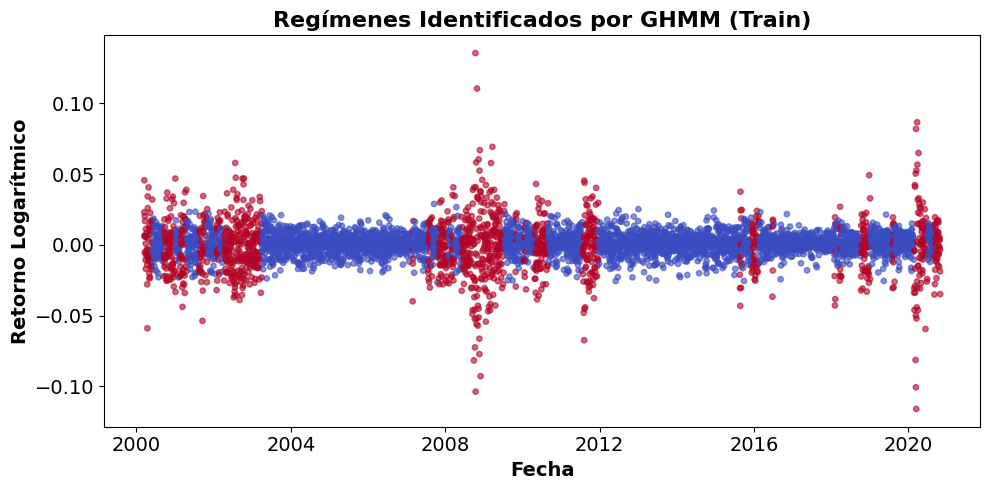


[Etapa 2] Segmentación por Régimen y Filtro Random Forest...
 -> Evaluando características para Régimen 0 (n=3787)...
    Conservadas: ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
 -> Evaluando características para Régimen 1 (n=1403)...
    Conservadas: ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']

[Etapa 3] Entrenando Clasificadores de Vectores de Soporte (Expertos)...
 -> Optimizando Experto 0 (Mercado Estable)...
 -> Optimizando Experto 1 (Mercado Volátil)...

[Etapa 4] Enrutamiento Dinámico (Fuera de Muestra)...

 Resultados Finales (Modelo Base 4.0)
Precisión Direccional: 57.63%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Baja (0)       0.57      0.27      0.36       587
    Alza (1)       0.58      0.83      0.68       711

    accuracy                           0.58      1298
   macro avg       0.57      0.55      0.52      1298
wei

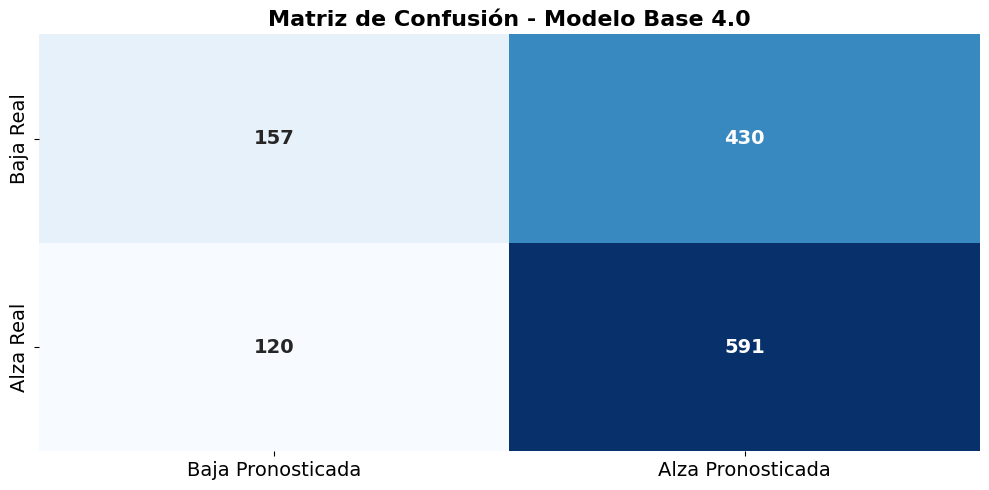


 RESULTADOS FINANCIEROS: ESTRATEGIA JERÁRQUICA PURA
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 169.84% | Drawdown: -9.97% | Sharpe: 1.63


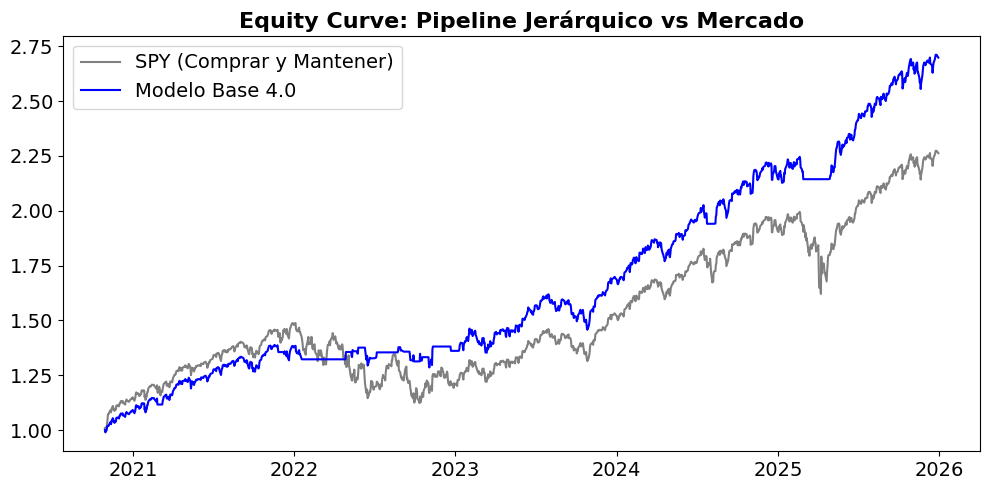

In [26]:
# --- CANDADOS DE DETERMINISMO TOTAL ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================
print("1. Cargando datos...")
ticker = "SPY"

# --- RUTAS HÍBRIDAS PARA COLAB ---
ruta_local = "/content/drive/MyDrive/datos_SPY_congelados.csv"
url_publica = "https://raw.githubusercontent.com/LeonardoMarquezJuarez/TU_REPOSITORIO/main/datos_SPY_congelados.csv"

if os.path.exists(ruta_local):
    print("-> Leyendo datos congelados desde tu Google Drive...")
    data = pd.read_csv(ruta_local, index_col=0, parse_dates=True)
else:
    print("-> Drive no detectado (entorno externo). Leyendo datos oficiales desde GitHub...")
    data = pd.read_csv(url_publica, index_col=0, parse_dates=True)

# --- CANDADO DE FECHA ESTRICTO ---
data = data.loc[:"2025-12-31"].copy()
print(f"📊 Dataset listo. Tamaño total: {len(data)} filas.")

# Identificador de precio
price_column = 'Adj Close' if 'Adj Close' in data.columns else 'Close'

# Objetivo: Retornos Logarítmicos
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))

# Ingeniería de Características
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
X_raw = data[feature_cols]
y_raw = data['Log_Return']

# REZAGO ESTRUCTURAL (Alinear X(t-1) con Y(t))
X_lagged = X_raw.shift(1)
dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()

y_returns = dataset['Log_Return']
X = dataset[feature_cols]

# CLASES BINARIAS (1 = Alza, 0 = Baja)
y_class = np.where(y_returns > 0, 1, 0)
y_class = pd.Series(y_class, index=y_returns.index)

# División Cronológica
split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_class, y_test_class = y_class.iloc[:split_idx], y_class.iloc[split_idx:]

# LA LÍNEA CORREGIDA: Declaramos tanto train como test para los retornos
y_train_returns, y_test_returns = y_returns.iloc[:split_idx], y_returns.iloc[split_idx:]# ==============================================================================
# ETAPA 1: IDENTIFICACIÓN DE REGÍMENES (GHMM con Candado de Varianza)
# ==============================================================================
print("\n[Etapa 1] Entrenando GaussianHMM...")
hmm_train_data = y_train_returns.values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_train_data)

regimes_train_raw = model_hmm.predict(hmm_train_data)
regimes_test_raw = model_hmm.predict(y_test_returns.values.reshape(-1, 1))

# CANDADO ANTI-LABEL SWITCHING: Forzamos el Régimen 1 a ser siempre alta volatilidad
var_estado_0 = np.var(hmm_train_data[regimes_train_raw == 0])
var_estado_1 = np.var(hmm_train_data[regimes_train_raw == 1])

if var_estado_0 > var_estado_1:
    regimes_train = 1 - regimes_train_raw
    regimes_test = 1 - regimes_test_raw
else:
    regimes_train = regimes_train_raw
    regimes_test = regimes_test_raw

# Visualizar la Segmentación
plt.figure(figsize=(10, 5))
plt.scatter(X_train.index, y_train_returns, c=regimes_train, cmap='coolwarm', alpha=0.6, s=15)
plt.title('Regímenes Identificados por GHMM (Train)', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=14, fontweight='bold')
plt.ylabel('Retorno Logarítmico', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# ==============================================================================
# ETAPA 2: DIVISIÓN JERÁRQUICA Y SELECCIÓN DE CARACTERÍSTICAS (Random Forest)
# ==============================================================================
print("\n[Etapa 2] Segmentación por Régimen y Filtro Random Forest...")
X_train_R0, y_train_R0 = X_train[regimes_train == 0], y_train_class[regimes_train == 0]
X_train_R1, y_train_R1 = X_train[regimes_train == 1], y_train_class[regimes_train == 1]

threshold = 0.05

# Gatekeeper Régimen 0
print(f" -> Evaluando características para Régimen 0 (n={len(X_train_R0)})...")
rf_R0 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf_R0.fit(X_train_R0, y_train_R0)
feats_R0 = [f for f, imp in zip(feature_cols, rf_R0.feature_importances_) if imp > threshold]
print(f"    Conservadas: {feats_R0}")

# Gatekeeper Régimen 1
print(f" -> Evaluando características para Régimen 1 (n={len(X_train_R1)})...")
rf_R1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf_R1.fit(X_train_R1, y_train_R1)
feats_R1 = [f for f, imp in zip(feature_cols, rf_R1.feature_importances_) if imp > threshold]
print(f"    Conservadas: {feats_R1}")

# Recortamos los datos para conservar solo las variables ganadoras
X_train_R0_filt = X_train_R0[feats_R0]
X_train_R1_filt = X_train_R1[feats_R1]

# Escalado Localizado
scaler_R0 = StandardScaler().fit(X_train_R0_filt)
scaler_R1 = StandardScaler().fit(X_train_R1_filt)
X_train_R0_scaled = scaler_R0.transform(X_train_R0_filt)
X_train_R1_scaled = scaler_R1.transform(X_train_R1_filt)

# ==============================================================================
# ETAPA 3: SVC LOCALIZADO Y PENALIZADO (Los Expertos)
# ==============================================================================
print("\n[Etapa 3] Entrenando Clasificadores de Vectores de Soporte (Expertos)...")
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]}
svc_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)

print(" -> Optimizando Experto 0 (Mercado Estable)...")
grid_R0 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
grid_R0.fit(X_train_R0_scaled, y_train_R0)
best_svc_R0 = grid_R0.best_estimator_

print(" -> Optimizando Experto 1 (Mercado Volátil)...")
grid_R1 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
grid_R1.fit(X_train_R1_scaled, y_train_R1)
best_svc_R1 = grid_R1.best_estimator_

# ==============================================================================
# ETAPA 4: ENRUTAMIENTO Y PRONÓSTICO FUERA DE LA MUESTRA
# ==============================================================================
print("\n[Etapa 4] Enrutamiento Dinámico (Fuera de Muestra)...")
y_pred_class = np.zeros(len(X_test))

# Enrutamos día a día evaluando el régimen en 't'
for i in range(len(X_test)):
    current_regime = regimes_test[i]

    if current_regime == 0:
        current_features = X_test.iloc[i][feats_R0].values.reshape(1, -1)
        scaled_features = scaler_R0.transform(current_features)
        y_pred_class[i] = best_svc_R0.predict(scaled_features)[0]
    else:
        current_features = X_test.iloc[i][feats_R1].values.reshape(1, -1)
        scaled_features = scaler_R1.transform(current_features)
        y_pred_class[i] = best_svc_R1.predict(scaled_features)[0]

# ==============================================================================
# 5. MÉTRICAS Y BACKTESTING FINANCIERO
# ==============================================================================
print("\n Resultados Finales (Modelo Base 4.0)")

test_acc = accuracy_score(y_test_class, y_pred_class)
print(f"Precisión Direccional: {test_acc * 100:.2f}%\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# Matriz de Confusión Visual
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"})
plt.tick_params(axis='both', which='major', labelsize=14)
plt.title('Matriz de Confusión - Modelo Base 4.0', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Backtesting Financiero
backtest_df = pd.DataFrame(index=y_test_class.index)
backtest_df['Market_Returns'] = y_test_returns
backtest_df['Signal'] = y_pred_class

backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
backtest_df.fillna(0, inplace=True)

backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

total_ret_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
total_ret_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100

sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: ESTRATEGIA JERÁRQUICA PURA")
print(f"Mercado    -> Retorno Total: {total_ret_mkt:.2f}% | Drawdown: {max_dd_mkt:.2f}% | Sharpe: {sharpe_mkt:.2f}")
print(f"Estrategia -> Retorno Total: {total_ret_str:.2f}% | Drawdown: {max_dd_str:.2f}% | Sharpe: {sharpe_str:.2f}")

plt.figure(figsize=(10,5))
plt.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray')
plt.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo Base 4.0', color='blue')
plt.title('Equity Curve: Pipeline Jerárquico vs Mercado', fontsize=16, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Ultimate baseline 4.0 all together

 BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO

PROCESANDO TICKER: QQQ (1/8)...
 -> Descargando QQQ de Yahoo Finance (Asegúrate de guardar el CSV)...
-> Dentro de Muestra : Prec. Dir.: 58.54%
-> Fuera de Muestra  : Prec. Dir.: 53.47%
-> Mercado           : Retorno:  135.41% | Max DD:  -35.12% | Sharpe: 0.74
-> Estrategia 4.0    : Retorno:   95.26% | Max DD:  -22.84% | Sharpe: 0.77

PROCESANDO TICKER: IWM (2/8)...
 -> Descargando IWM de Yahoo Finance (Asegúrate de guardar el CSV)...


-> Dentro de Muestra : Prec. Dir.: 52.46%
-> Fuera de Muestra  : Prec. Dir.: 51.72%
-> Mercado           : Retorno:   44.11% | Max DD:  -31.91% | Sharpe: 0.32
-> Estrategia 4.0    : Retorno:   72.64% | Max DD:  -13.71% | Sharpe: 1.03

PROCESANDO TICKER: EEM (3/8)...
 -> Descargando EEM de Yahoo Finance (Asegúrate de guardar el CSV)...


-> Dentro de Muestra : Prec. Dir.: 64.78%
-> Fuera de Muestra  : Prec. Dir.: 49.91%
-> Mercado           : Retorno:   11.57% | Max DD:  -37.49% | Sharpe: 0.13
-> Estrategia 4.0    : Retorno:  -27.65% | Max DD:  -34.42% | Sharpe: -0.63

PROCESANDO TICKER: GLD (4/8)...
 -> Descargando GLD de Yahoo Finance (Asegúrate de guardar el CSV)...
-> Dentro de Muestra : Prec. Dir.: 54.12%
-> Fuera de Muestra  : Prec. Dir.: 50.81%
-> Mercado           : Retorno:  141.09% | Max DD:  -21.03% | Sharpe: 1.33
-> Estrategia 4.0    : Retorno:   63.49% | Max DD:  -11.89% | Sharpe: 1.05

PROCESANDO TICKER: TLT (5/8)...
 -> Descargando TLT de Yahoo Finance (Asegúrate de guardar el CSV)...
-> Dentro de Muestra : Prec. Dir.: 62.20%
-> Fuera de Muestra  : Prec. Dir.: 53.81%
-> Mercado           : Retorno:  -26.83% | Max DD:  -43.70% | Sharpe: -0.41
-> Estrategia 4.0    : Retorno:   12.01% | Max DD:  -16.46% | Sharpe: 0.23

PROCESANDO TICKER: XLE (6/8)...
 -> Descargando XLE de Yahoo Finance (Asegúrate de guarda

-> Dentro de Muestra : Prec. Dir.: 64.10%
-> Fuera de Muestra  : Prec. Dir.: 51.54%
-> Mercado           : Retorno:  139.48% | Max DD:  -31.17% | Sharpe: 0.76
-> Estrategia 4.0    : Retorno:  102.25% | Max DD:  -13.58% | Sharpe: 1.02

PROCESANDO TICKER: VXX (8/8)...
 -> Descargando VXX de Yahoo Finance (Asegúrate de guardar el CSV)...
-> Dentro de Muestra : Prec. Dir.: 60.71%
-> Fuera de Muestra  : Prec. Dir.: 50.39%
-> Mercado           : Retorno:  -40.86% | Max DD:  -69.88% | Sharpe: -0.42
-> Estrategia 4.0    : Retorno:   -6.53% | Max DD:  -50.64% | Sharpe: -0.10


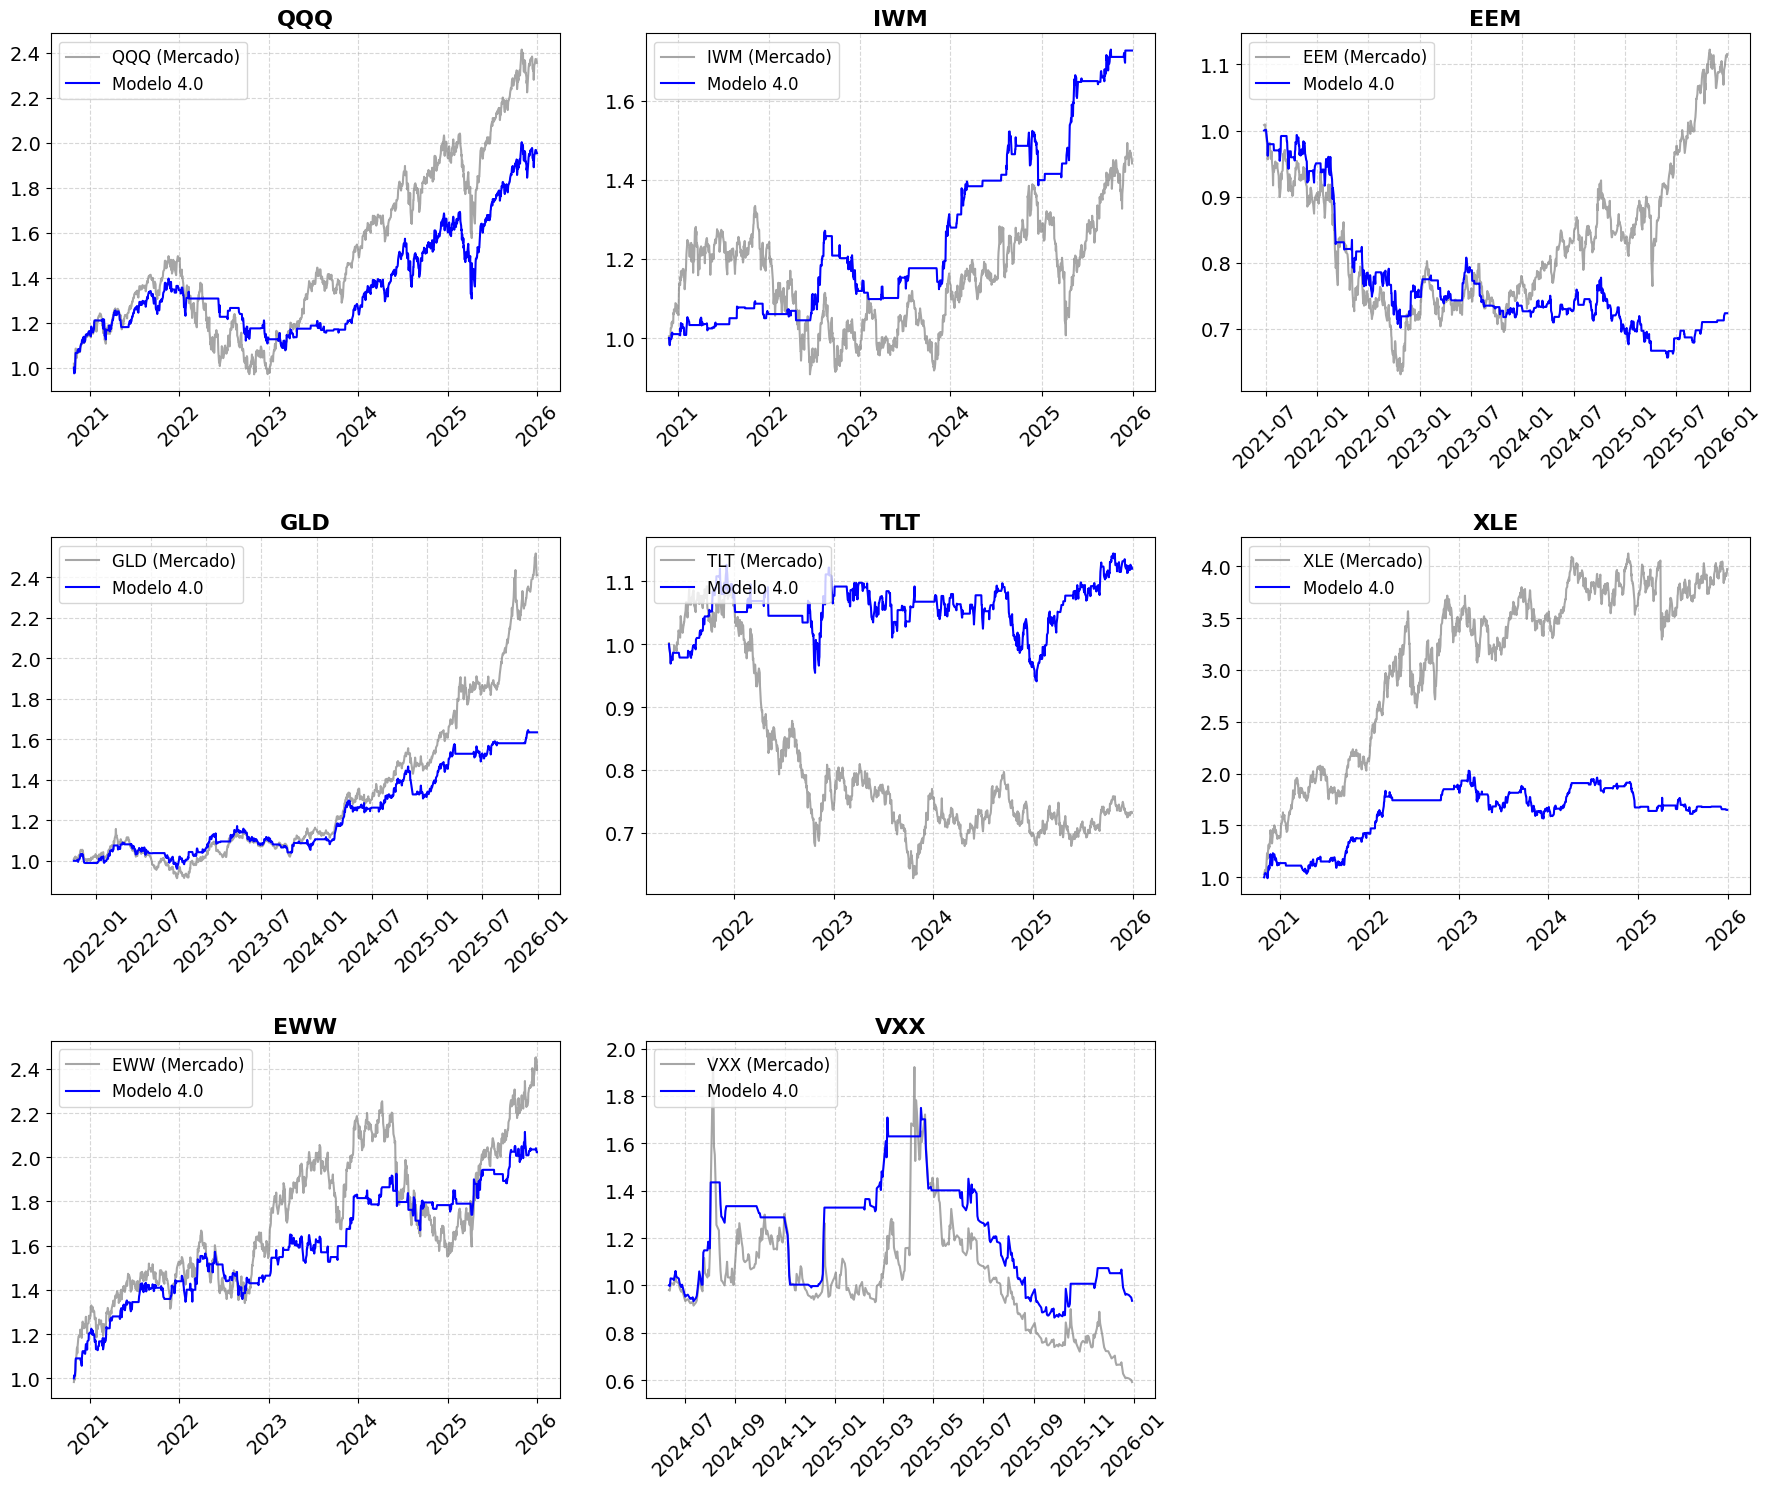

In [27]:
# --- 1. CANDADOS DE DETERMINISMO ABSOLUTO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

print(" BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO")
tickers = ["QQQ", "IWM", "EEM", "GLD", "TLT", "XLE", "EWW", "VXX"]

# LÓGICA DE GRÁFICOS: Cuadrícula Académica
num_tickers = len(tickers)
cols = 3
rows = math.ceil(num_tickers / cols)

# Crear una figura ancha y perfectamente proporcionada
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten() # Aplanar la matriz para iterar fácilmente

for idx, ticker in enumerate(tickers):
    print(f"\n==================================================")
    print(f"PROCESANDO TICKER: {ticker} ({idx+1}/{num_tickers})...")
    print(f"==================================================")

    # --- INGENIERÍA DE DATOS (RUTAS HÍBRIDAS ULTRA-ROBUSTAS) ---
    ruta_local = f"/content/drive/MyDrive/datos_{ticker}_congelados.csv"
    url_publica = f"https://raw.githubusercontent.com/LeonardoMarquezJuarez/TU_REPOSITORIO/main/datos_{ticker}_congelados.csv"

    if os.path.exists(ruta_local):
        print(f" -> Leyendo {ticker} desde tu Google Drive...")
        data = pd.read_csv(ruta_local, index_col=0, parse_dates=True)
    else:
        try:
            # Intenta buscar en GitHub si Drive no está
            data = pd.read_csv(url_publica, index_col=0, parse_dates=True)
            print(f" -> Leyendo {ticker} desde repositorio de GitHub...")
        except Exception:
            # Fallback a yfinance si el archivo aún no existe, pero con candado de fecha
            print(f" -> Descargando {ticker} de Yahoo Finance (Asegúrate de guardar el CSV)...")
            data = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
            if isinstance(data.columns, pd.MultiIndex):
                data.columns = data.columns.get_level_values(0)

    # CANDADO DE FECHA ESTRICTO
    data = data.loc[:"2025-12-31"].copy()

    price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
    data['Log_Return'] = np.log(data[price_col] / data[price_col].shift(1))

    data['SMA_15'] = data[price_col].rolling(window=15).mean()
    data['SMA_50'] = data[price_col].rolling(window=50).mean()
    data['Momentum_5D'] = data[price_col] / data[price_col].shift(5) - 1
    data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
    data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
    data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
    data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

    feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
    X_raw = data[feature_cols]
    y_raw = data['Log_Return']

    # REZAGO ESTRUCTURAL
    X_lagged = X_raw.shift(1)
    dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()

    y_returns = dataset['Log_Return']
    X = dataset[feature_cols]

    # Clases Binarias
    y_class = np.where(y_returns > 0, 1, 0)
    y_class = pd.Series(y_class, index=y_returns.index)

    split_idx = int(len(dataset) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train_class, y_test_class = y_class.iloc[:split_idx], y_class.iloc[split_idx:]
    y_train_returns, y_test_returns = y_returns.iloc[:split_idx], y_returns.iloc[split_idx:]

    # --- ETAPA 1: IDENTIFICACIÓN DE REGÍMENES (GHMM) ---
    hmm_train_data = y_train_returns.values.reshape(-1, 1)
    model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
    model_hmm.fit(hmm_train_data)

    regimes_train_raw = model_hmm.predict(hmm_train_data)
    regimes_test_raw = model_hmm.predict(y_test_returns.values.reshape(-1, 1))

    # CANDADO ANTI-LABEL SWITCHING
    var_estado_0 = np.var(hmm_train_data[regimes_train_raw == 0])
    var_estado_1 = np.var(hmm_train_data[regimes_train_raw == 1])

    if var_estado_0 > var_estado_1:
        regimes_train = 1 - regimes_train_raw
        regimes_test = 1 - regimes_test_raw
    else:
        regimes_train = regimes_train_raw
        regimes_test = regimes_test_raw

    # --- ETAPA 2: FILTRO RANDOM FOREST LOCALIZADO ---
    X_train_R0, y_train_R0 = X_train[regimes_train == 0], y_train_class[regimes_train == 0]
    X_train_R1, y_train_R1 = X_train[regimes_train == 1], y_train_class[regimes_train == 1]

    threshold = 0.05
    rf_R0 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1).fit(X_train_R0, y_train_R0)
    feats_R0 = [f for f, imp in zip(feature_cols, rf_R0.feature_importances_) if imp > threshold]

    rf_R1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1).fit(X_train_R1, y_train_R1)
    feats_R1 = [f for f, imp in zip(feature_cols, rf_R1.feature_importances_) if imp > threshold]

    X_train_R0_filt = X_train_R0[feats_R0]
    X_train_R1_filt = X_train_R1[feats_R1]

    # --- ETAPA 3: ESCALADO Y ENTRENAMIENTO SVC LOCALIZADO ---
    scaler_R0 = StandardScaler().fit(X_train_R0_filt)
    scaler_R1 = StandardScaler().fit(X_train_R1_filt)

    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01]}
    svc_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)

    grid_R0 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R0.fit(scaler_R0.transform(X_train_R0_filt), y_train_R0)
    best_svc_R0 = grid_R0.best_estimator_

    grid_R1 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R1.fit(scaler_R1.transform(X_train_R1_filt), y_train_R1)
    best_svc_R1 = grid_R1.best_estimator_

    # --- ENRUTAMIENTO DINÁMICO DENTRO DE MUESTRA ---
    y_pred_train_class = np.zeros(len(X_train))
    for i in range(len(X_train)):
        if regimes_train[i] == 0:
            current_feats = X_train.iloc[i][feats_R0].values.reshape(1, -1)
            y_pred_train_class[i] = best_svc_R0.predict(scaler_R0.transform(current_feats))[0]
        else:
            current_feats = X_train.iloc[i][feats_R1].values.reshape(1, -1)
            y_pred_train_class[i] = best_svc_R1.predict(scaler_R1.transform(current_feats))[0]

    # --- ENRUTAMIENTO DINÁMICO FUERA DE MUESTRA ---
    y_pred_class = np.zeros(len(X_test))
    for i in range(len(X_test)):
        if regimes_test[i] == 0:
            current_feats = X_test.iloc[i][feats_R0].values.reshape(1, -1)
            y_pred_class[i] = best_svc_R0.predict(scaler_R0.transform(current_feats))[0]
        else:
            current_feats = X_test.iloc[i][feats_R1].values.reshape(1, -1)
            y_pred_class[i] = best_svc_R1.predict(scaler_R1.transform(current_feats))[0]

    # --- BACKTESTING FINANCIERO Y CÁLCULO DE MÉTRICAS ---
    backtest_df = pd.DataFrame(index=y_test_class.index)
    backtest_df['Market_Returns'] = y_test_returns
    backtest_df['Signal'] = y_pred_class

    backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
    backtest_df.fillna(0, inplace=True)

    backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
    backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

    total_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
    total_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100
    max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
    max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100
    sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
    sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

    train_acc = accuracy_score(y_train_class, y_pred_train_class)
    test_acc = accuracy_score(y_test_class, y_pred_class)

    print(f"-> Dentro de Muestra : Prec. Dir.: {train_acc*100:.2f}%")
    print(f"-> Fuera de Muestra  : Prec. Dir.: {test_acc*100:.2f}%")
    print(f"-> Mercado           : Retorno: {total_mkt:>7.2f}% | Max DD: {max_dd_mkt:>7.2f}% | Sharpe: {sharpe_mkt:.2f}")
    print(f"-> Estrategia 4.0    : Retorno: {total_str:>7.2f}% | Max DD: {max_dd_str:>7.2f}% | Sharpe: {sharpe_str:.2f}")

    # --- GRAFICAR EN LA CUADRÍCULA ACADÉMICA ---
    ax = axes[idx]
    ax.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Mercado)', color='gray', alpha=0.7)
    ax.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo 4.0', color='blue', linewidth=1.5)

    # Ajustes estéticos institucionales (Tesis)
    ax.set_title(f'{ticker}', fontsize=16, fontweight='bold')
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

# --- FIN DEL BUCLE FOR ---

# Limpiar cualquier subgráfico vacío si la última imagen no se llena completa
for j in range(num_tickers, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(h_pad=3.0, w_pad=2.0)
plt.show()

 BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO (VISUALIZACIÓN 2x2)

PROCESANDO TICKER: QQQ (1/8)...
 -> Descargando QQQ de Yahoo Finance por ÚLTIMA VEZ...
-> Dentro de Muestra : Prec. Dir.: 58.54%
-> Fuera de Muestra  : Prec. Dir.: 53.47%
-> Mercado           : Retorno:  135.41% | Max DD:  -35.12% | Sharpe: 0.74
-> Estrategia 4.0    : Retorno:   95.26% | Max DD:  -22.84% | Sharpe: 0.77

PROCESANDO TICKER: IWM (2/8)...
 -> Descargando IWM de Yahoo Finance por ÚLTIMA VEZ...


-> Dentro de Muestra : Prec. Dir.: 52.46%
-> Fuera de Muestra  : Prec. Dir.: 51.72%
-> Mercado           : Retorno:   44.11% | Max DD:  -31.91% | Sharpe: 0.32
-> Estrategia 4.0    : Retorno:   72.64% | Max DD:  -13.71% | Sharpe: 1.03

PROCESANDO TICKER: EEM (3/8)...
 -> Descargando EEM de Yahoo Finance por ÚLTIMA VEZ...


-> Dentro de Muestra : Prec. Dir.: 64.78%
-> Fuera de Muestra  : Prec. Dir.: 49.91%
-> Mercado           : Retorno:   11.57% | Max DD:  -37.49% | Sharpe: 0.13
-> Estrategia 4.0    : Retorno:  -27.65% | Max DD:  -34.42% | Sharpe: -0.63

PROCESANDO TICKER: GLD (4/8)...
 -> Descargando GLD de Yahoo Finance por ÚLTIMA VEZ...
-> Dentro de Muestra : Prec. Dir.: 54.12%
-> Fuera de Muestra  : Prec. Dir.: 50.81%
-> Mercado           : Retorno:  141.09% | Max DD:  -21.03% | Sharpe: 1.33
-> Estrategia 4.0    : Retorno:   63.49% | Max DD:  -11.89% | Sharpe: 1.05


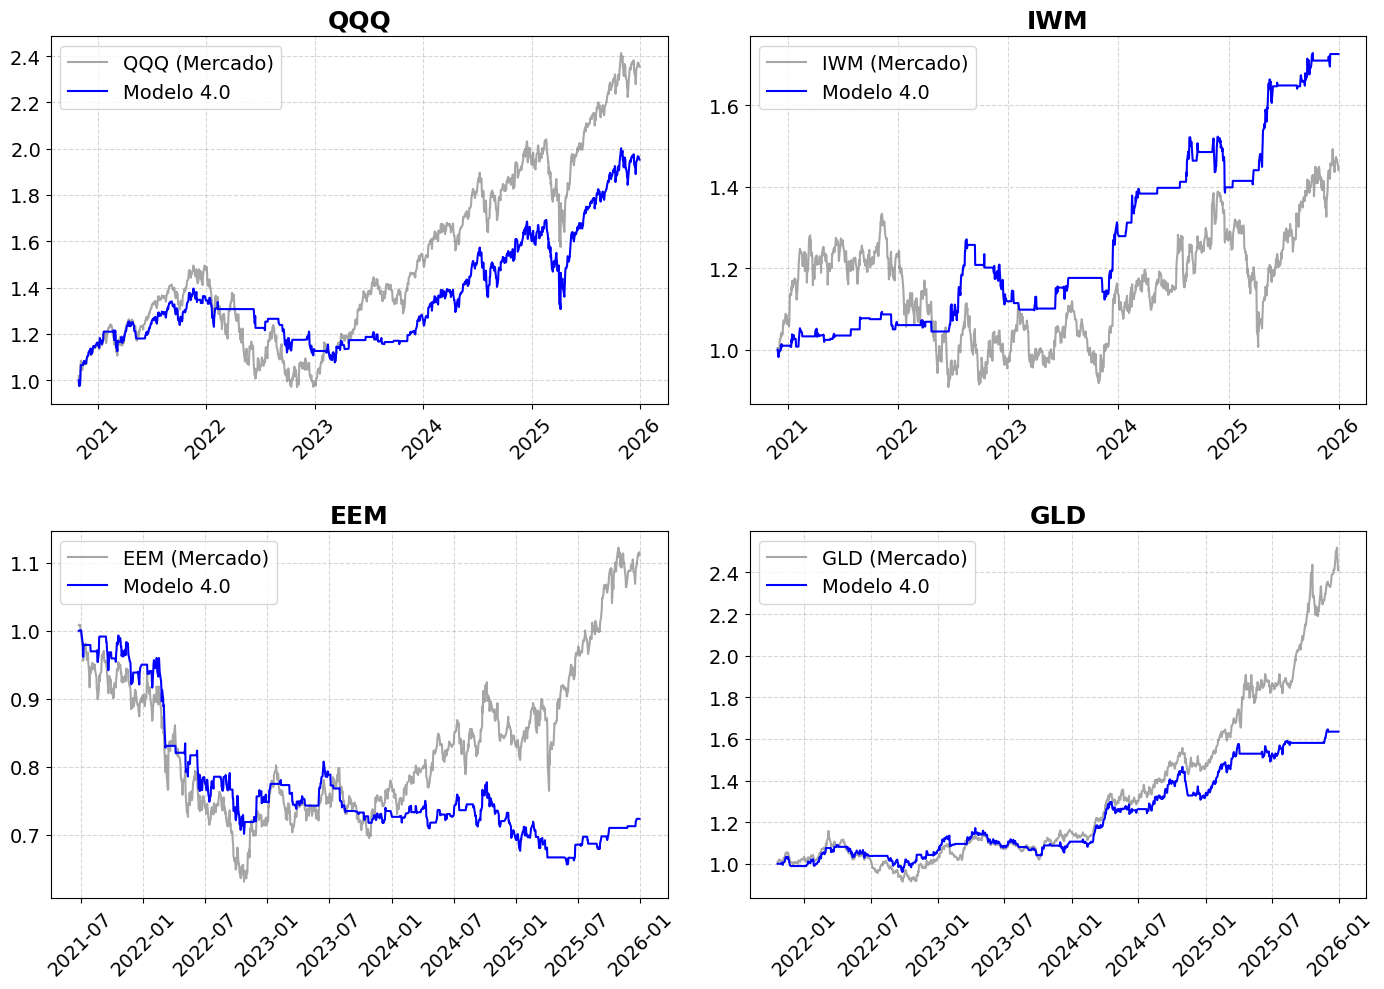


PROCESANDO TICKER: TLT (5/8)...
 -> Descargando TLT de Yahoo Finance por ÚLTIMA VEZ...
-> Dentro de Muestra : Prec. Dir.: 62.20%
-> Fuera de Muestra  : Prec. Dir.: 53.81%
-> Mercado           : Retorno:  -26.83% | Max DD:  -43.70% | Sharpe: -0.41
-> Estrategia 4.0    : Retorno:   12.01% | Max DD:  -16.46% | Sharpe: 0.23

PROCESANDO TICKER: XLE (6/8)...
 -> Descargando XLE de Yahoo Finance por ÚLTIMA VEZ...
-> Dentro de Muestra : Prec. Dir.: 64.41%
-> Fuera de Muestra  : Prec. Dir.: 49.46%
-> Mercado           : Retorno:  297.25% | Max DD:  -26.04% | Sharpe: 0.95
-> Estrategia 4.0    : Retorno:   65.06% | Max DD:  -22.74% | Sharpe: 0.57

PROCESANDO TICKER: EWW (7/8)...
 -> Descargando EWW de Yahoo Finance por ÚLTIMA VEZ...


-> Dentro de Muestra : Prec. Dir.: 64.10%
-> Fuera de Muestra  : Prec. Dir.: 51.54%
-> Mercado           : Retorno:  139.48% | Max DD:  -31.17% | Sharpe: 0.76
-> Estrategia 4.0    : Retorno:  102.25% | Max DD:  -13.58% | Sharpe: 1.02

PROCESANDO TICKER: VXX (8/8)...
 -> Descargando VXX de Yahoo Finance por ÚLTIMA VEZ...
-> Dentro de Muestra : Prec. Dir.: 60.71%
-> Fuera de Muestra  : Prec. Dir.: 50.39%
-> Mercado           : Retorno:  -40.86% | Max DD:  -69.88% | Sharpe: -0.42
-> Estrategia 4.0    : Retorno:   -6.53% | Max DD:  -50.64% | Sharpe: -0.10


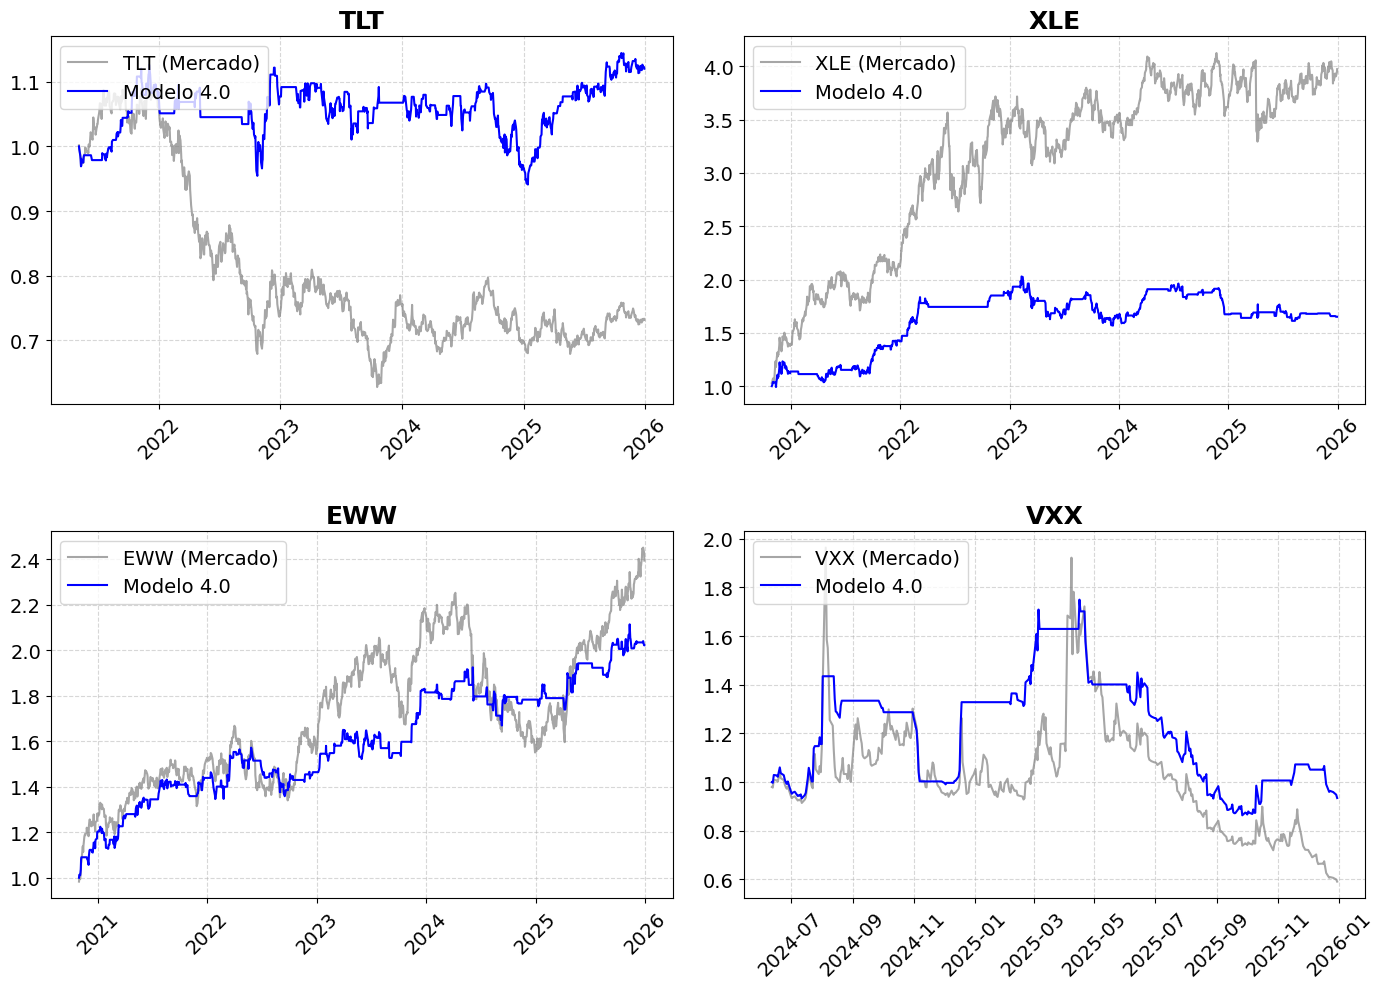

In [28]:
import os
import random
import numpy as np
import pandas as pd
import warnings
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import matplotlib.pyplot as plt

# --- 1. CANDADOS DE DETERMINISMO ABSOLUTO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

print(" BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO (VISUALIZACIÓN 2x2)")
tickers = ["QQQ", "IWM", "EEM", "GLD", "TLT", "XLE", "EWW", "VXX"]
num_tickers = len(tickers)

# --- LÓGICA DE GRÁFICOS: Dos imágenes con 4 activos cada una ---
activos_por_imagen = 4
cols = 2
rows = 2

fig = None
axes = None
ax_idx = 0

for idx, ticker in enumerate(tickers):

    # Si estamos en el primer activo de un nuevo grupo de 4, creamos una nueva figura
    if idx % activos_por_imagen == 0:
        fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
        axes = axes.flatten()
        ax_idx = 0 # Reiniciamos el índice del eje para la nueva figura

    print(f"\n==================================================")
    print(f"PROCESANDO TICKER: {ticker} ({idx+1}/{num_tickers})...")
    print(f"==================================================")

    # --- INGENIERÍA DE DATOS (RUTAS HÍBRIDAS ULTRA-ROBUSTAS) ---
    ruta_local = f"/content/drive/MyDrive/datos_{ticker}_congelados.csv"
    url_publica = f"https://raw.githubusercontent.com/LeonardoMarquezJuarez/TU_REPOSITORIO/main/datos_{ticker}_congelados.csv"

    if os.path.exists(ruta_local):
        print(f" -> Leyendo {ticker} desde tu Google Drive...")
        data = pd.read_csv(ruta_local, index_col=0, parse_dates=True)
    else:
        try:
            data = pd.read_csv(url_publica, index_col=0, parse_dates=True)
            print(f" -> Leyendo {ticker} desde repositorio de GitHub...")
        except Exception:
            print(f" -> Descargando {ticker} de Yahoo Finance por ÚLTIMA VEZ...")
            data = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
            if isinstance(data.columns, pd.MultiIndex):
                data.columns = data.columns.get_level_values(0)

    # CANDADO DE FECHA ESTRICTO
    data = data.loc[:"2025-12-31"].copy()

    price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
    data['Log_Return'] = np.log(data[price_col] / data[price_col].shift(1))

    # Incorporación de TODAS las características (incluyendo asimetría y curtosis)
    data['SMA_15'] = data[price_col].rolling(window=15).mean()
    data['SMA_50'] = data[price_col].rolling(window=50).mean()
    data['Momentum_5D'] = data[price_col] / data[price_col].shift(5) - 1
    data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
    data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
    data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
    data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

    feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
    X_raw = data[feature_cols]
    y_raw = data['Log_Return']

    # REZAGO ESTRUCTURAL
    X_lagged = X_raw.shift(1)
    dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()

    y_returns = dataset['Log_Return']
    X = dataset[feature_cols]

    y_class = np.where(y_returns > 0, 1, 0)
    y_class = pd.Series(y_class, index=y_returns.index)

    split_idx = int(len(dataset) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train_class, y_test_class = y_class.iloc[:split_idx], y_class.iloc[split_idx:]
    y_train_returns, y_test_returns = y_returns.iloc[:split_idx], y_returns.iloc[split_idx:]

    # --- ETAPA 1: IDENTIFICACIÓN DE REGÍMENES (GHMM) ---
    hmm_train_data = y_train_returns.values.reshape(-1, 1)
    model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
    model_hmm.fit(hmm_train_data)

    regimes_train_raw = model_hmm.predict(hmm_train_data)
    regimes_test_raw = model_hmm.predict(y_test_returns.values.reshape(-1, 1))

    # CANDADO ANTI-LABEL SWITCHING (Vital para iterar múltiples activos)
    var_estado_0 = np.var(hmm_train_data[regimes_train_raw == 0])
    var_estado_1 = np.var(hmm_train_data[regimes_train_raw == 1])

    if var_estado_0 > var_estado_1:
        regimes_train = 1 - regimes_train_raw
        regimes_test = 1 - regimes_test_raw
    else:
        regimes_train = regimes_train_raw
        regimes_test = regimes_test_raw

    # --- ETAPA 2: FILTRO RANDOM FOREST LOCALIZADO ---
    X_train_R0, y_train_R0 = X_train[regimes_train == 0], y_train_class[regimes_train == 0]
    X_train_R1, y_train_R1 = X_train[regimes_train == 1], y_train_class[regimes_train == 1]

    threshold = 0.05
    rf_R0 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1).fit(X_train_R0, y_train_R0)
    feats_R0 = [f for f, imp in zip(feature_cols, rf_R0.feature_importances_) if imp > threshold]

    rf_R1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1).fit(X_train_R1, y_train_R1)
    feats_R1 = [f for f, imp in zip(feature_cols, rf_R1.feature_importances_) if imp > threshold]

    X_train_R0_filt = X_train_R0[feats_R0]
    X_train_R1_filt = X_train_R1[feats_R1]

    # --- ETAPA 3: ESCALADO Y ENTRENAMIENTO SVC LOCALIZADO ---
    scaler_R0 = StandardScaler().fit(X_train_R0_filt)
    scaler_R1 = StandardScaler().fit(X_train_R1_filt)

    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01]}
    svc_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)

    grid_R0 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R0.fit(scaler_R0.transform(X_train_R0_filt), y_train_R0)
    best_svc_R0 = grid_R0.best_estimator_

    grid_R1 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R1.fit(scaler_R1.transform(X_train_R1_filt), y_train_R1)
    best_svc_R1 = grid_R1.best_estimator_

    # --- ENRUTAMIENTO DINÁMICO DENTRO DE MUESTRA ---
    y_pred_train_class = np.zeros(len(X_train))
    for i in range(len(X_train)):
        if regimes_train[i] == 0:
            current_feats = X_train.iloc[i][feats_R0].values.reshape(1, -1)
            y_pred_train_class[i] = best_svc_R0.predict(scaler_R0.transform(current_feats))[0]
        else:
            current_feats = X_train.iloc[i][feats_R1].values.reshape(1, -1)
            y_pred_train_class[i] = best_svc_R1.predict(scaler_R1.transform(current_feats))[0]

    # --- ENRUTAMIENTO DINÁMICO FUERA DE MUESTRA ---
    y_pred_class = np.zeros(len(X_test))
    for i in range(len(X_test)):
        if regimes_test[i] == 0:
            current_feats = X_test.iloc[i][feats_R0].values.reshape(1, -1)
            y_pred_class[i] = best_svc_R0.predict(scaler_R0.transform(current_feats))[0]
        else:
            current_feats = X_test.iloc[i][feats_R1].values.reshape(1, -1)
            y_pred_class[i] = best_svc_R1.predict(scaler_R1.transform(current_feats))[0]

    # --- BACKTESTING FINANCIERO Y CÁLCULO DE MÉTRICAS ---
    backtest_df = pd.DataFrame(index=y_test_class.index)
    backtest_df['Market_Returns'] = y_test_returns
    backtest_df['Signal'] = y_pred_class

    backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
    backtest_df.fillna(0, inplace=True)

    backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
    backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

    total_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
    total_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100
    max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
    max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100
    sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
    sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

    train_acc = accuracy_score(y_train_class, y_pred_train_class)
    test_acc = accuracy_score(y_test_class, y_pred_class)

    print(f"-> Dentro de Muestra : Prec. Dir.: {train_acc*100:.2f}%")
    print(f"-> Fuera de Muestra  : Prec. Dir.: {test_acc*100:.2f}%")
    print(f"-> Mercado           : Retorno: {total_mkt:>7.2f}% | Max DD: {max_dd_mkt:>7.2f}% | Sharpe: {sharpe_mkt:.2f}")
    print(f"-> Estrategia 4.0    : Retorno: {total_str:>7.2f}% | Max DD: {max_dd_str:>7.2f}% | Sharpe: {sharpe_str:.2f}")

    # --- GRAFICAR EN LA CUADRÍCULA ACADÉMICA ---
    ax = axes[ax_idx]
    ax.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Mercado)', color='gray', alpha=0.7)
    ax.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo 4.0', color='blue', linewidth=1.5)

    # Textos más grandes para la impresión de la Tesis
    ax.set_title(f'{ticker}', fontsize=18, fontweight='bold')
    ax.legend(loc='upper left', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax_idx += 1

    # --- CONDICIÓN DE CORTE PARA MOSTRAR LA IMAGEN ---
    if (idx + 1) % activos_por_imagen == 0 or (idx + 1) == num_tickers:
        if (idx + 1) == num_tickers and (idx + 1) % activos_por_imagen != 0:
             for j in range(ax_idx, len(axes)):
                 fig.delaxes(axes[j])

        plt.tight_layout(h_pad=3.0, w_pad=2.0)
        plt.show()